# 🎯 Simone — MVG Enhanced & Financial Context
## Split: Walk-Forward

**Business Case 4 — Early Warning System**

---

## Scope of this notebook

This notebook is the **Simone contribution** to the group project.
It builds on the professor's baseline MVG model and extends it in four directions:

1. **MVG Baseline** — the reference model from the professor's notebook (reproduced here for self-containment).
2. **MVG + Ledoit-Wolf** — replacing the sample covariance with a shrinkage estimator.
3. **Elliptic Envelope** — a robust, sklearn-native elliptic anomaly detector.
4. **MVG CDF-based** — replacing the PDF score with the multivariate CDF, more robust to asymmetries.
5. **MVG Asymmetric** — adding a financial discriminating variable (VIX / equity) to filter out "anomalously good" markets.

Additionally:
- **Dimensionality reduction** visualizations: t-SNE, PACMAP, Spectral Embedding.
- **Synthetic data experiments** to understand model behavior.
- **Feature importance** via permutation on the MVG.

All models are evaluated with the same metrics: **Precision, Recall, F1, AUC** and appended to a shared `results_df`.

---

## 📦 Imports & Setup

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import multivariate_normal

# Sklearn — preprocessing, metrics, models
from sklearn.utils import shuffle
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, SpectralEmbedding
from sklearn.covariance import LedoitWolf, EllipticEnvelope

# Visualization style — follow professor's notebook
sns.set_theme(style="whitegrid")
sns.set_context("notebook", font_scale=1.5)
plt.rcParams['figure.figsize'] = [12, 8]


print("All imports OK.")


All imports OK.


In [2]:
# Install PACMAP if not available (uncomment if needed)
# !pip install pacmap -q
import importlib
pacmap_available = importlib.util.find_spec('pacmap') is not None
if pacmap_available:
    import pacmap
    print("PACMAP available.")
else:
    print("PACMAP not installed. Run: pip install pacmap")
    print("Skipping PACMAP visualizations.")

PACMAP not installed. Run: pip install pacmap
Skipping PACMAP visualizations.


---

## 📂 Data Loading

We load the Bloomberg weekly dataset from `Dataset4_EWS.xlsx`.

- **Sheet `Markets`**: weekly observations of ~40 financial variables + label `Y` (0 = normal, 1 = anomalous/risk-off).
- **Sheet `Metadata`**: variable descriptions.

<br>

In [3]:
# File path — dataset is in the data/ subfolder
import os
file_path = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'data', 'Dataset4_EWS.xlsx')

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

# Load the data
data_df = pd.read_excel(file_path, sheet_name='Markets')
metadata_df = pd.read_excel(file_path, sheet_name='Metadata')

# Check the structure
print("Data columns:", data_df.columns.tolist())

# Extract date and label columns
date_col = 'Date' if 'Date' in data_df.columns else data_df.columns[0]
y_col = 'Y' if 'Y' in data_df.columns else None

# Parse dates
data_df[date_col] = pd.to_datetime(data_df[date_col], dayfirst=True)
data_df = data_df.set_index(date_col)

# Split features and label
if y_col:
    X_df = data_df.drop(y_col, axis=1)
    y = data_df[y_col].values
else:
    X_df = data_df
    y = None

# Summary
print(f"\nData shape: {X_df.shape}")
print(f"Period: {X_df.index.min().strftime('%Y-%m-%d')} → {X_df.index.max().strftime('%Y-%m-%d')}")
print(f"Number of variables: {X_df.shape[1]}")
if y is not None:
    print(f"Anomalies (Y=1): {np.sum(y == 1)} ({np.mean(y == 1)*100:.2f}%)")
    print(f"Normal   (Y=0): {np.sum(y == 0)} ({np.mean(y == 0)*100:.2f}%)")

Data columns: ['Data', 'BDIY', 'CRY', 'Cl1', 'DXY', 'ECSURPUS', 'EMUSTRUU', 'EONIA', 'GBP', 'GT10', 'GTDEM10Y', 'GTDEM2Y', 'GTDEM30Y', 'GTGBP20Y', 'GTGBP2Y', 'GTGBP30Y', 'GTITL10YR', 'GTITL2YR', 'GTITL30YR', 'GTJPY10YR', 'GTJPY2YR', 'GTJPY30YR', 'JPY', 'LF94TRUU', 'LF98TRUU', 'LG30TRUU', 'LMBITR', 'LP01TREU', 'LUACTRUU', 'LUMSTRUU', 'MXBR', 'MXCN', 'MXEU', 'MXIN', 'MXJP', 'MXRU', 'MXUS', 'US0001M', 'USGG2YR', 'USGG30YR', 'USGG3M', 'VIX', 'XAUBGNL', 'Y']

Data shape: (1111, 42)
Period: 2000-01-11 → 2021-04-20
Number of variables: 42
Anomalies (Y=1): 237 (21.33%)
Normal   (Y=0): 874 (78.67%)


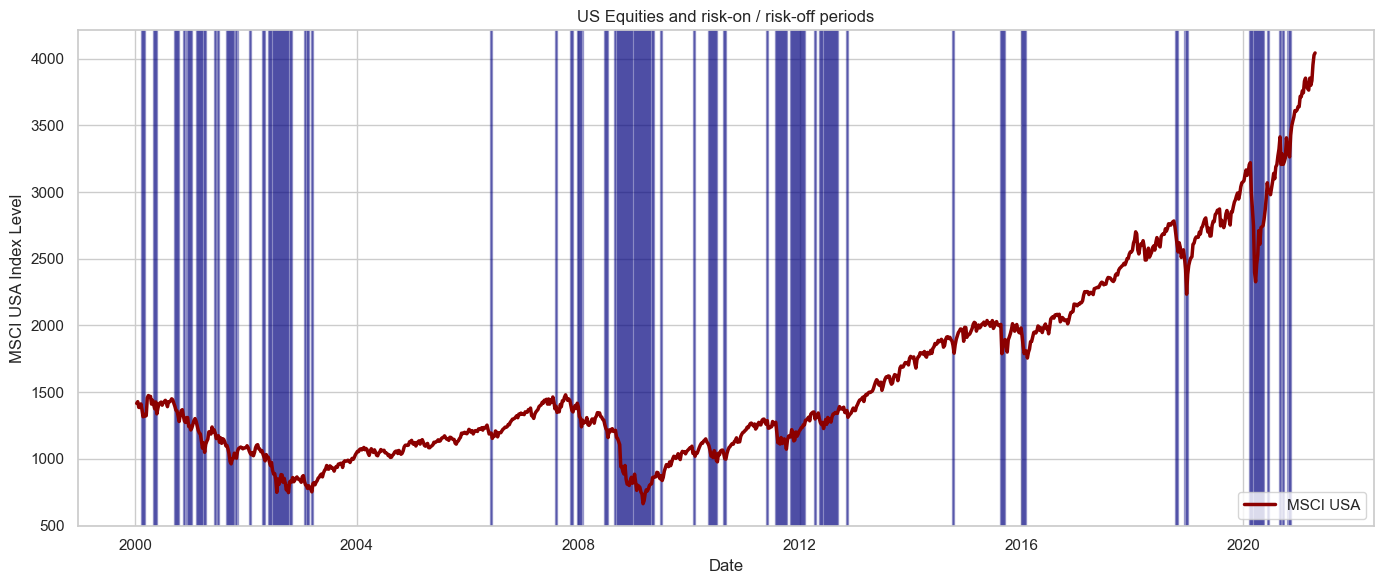

In [4]:
# Visual overview: MSCI USA with risk-off periods highlighted
if y_col and 'MXUS' in X_df.columns:
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(X_df.index, X_df['MXUS'], color='darkred', linewidth=2.5, label='MSCI USA')

    for i, (date, is_anomaly) in enumerate(zip(X_df.index, y)):
        if is_anomaly == 1:
            ax.axvspan(date, date + pd.Timedelta(days=7),
                       alpha=0.3, color='navy',
                       label='Risk-off (Y=1)' if i == 0 else "")

    ax.set_xlabel('Date')
    ax.set_ylabel('MSCI USA Index Level')
    ax.set_title('US Equities and risk-on / risk-off periods')
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(dict(zip(labels, handles)).values(), dict(zip(labels, handles)).keys(), loc='best')
    plt.tight_layout()
    plt.show()

---

## 🔄 Stationarity Transformation

We need all features to be **stationary** before modeling.

| Variable type | Transformation | Reason |
|---|---|---|
| Indices, currencies, commodities | **log-difference** | Always positive → multiplicative dynamics |
| Interest rates, yields | **first difference** | Can be negative or near zero |
| Economic Surprise Index | **as-is** | Already roughly stationary |

Only the **features** are transformed — not the label `Y`.

<br>

In [5]:
# Define variable groups by transformation type
indices_currencies = [col for col in X_df.columns if col in [
    'XAUBGNL', 'BDIY', 'CRY', 'Cl1', 'DXY', 'EMUSTRUU', 'GBP', 'JPY', 'LF94TRUU',
    'LF98TRUU', 'LG30TRUU', 'LMBITR', 'LP01TREU', 'LUACTRUU', 'LUMSTRUU',
    'MXBR', 'MXCN', 'MXEU', 'MXIN', 'MXJP', 'MXRU', 'MXUS', 'VIX'
]]

interest_rates = [col for col in X_df.columns if col in [
    'EONIA', 'GTDEM10Y', 'GTDEM2Y', 'GTDEM30Y', 'GTGBP20Y', 'GTGBP2Y', 'GTGBP30Y',
    'GTITL10YR', 'GTITL2YR', 'GTITL30YR', 'GTJPY10YR', 'GTJPY2YR', 'GTJPY30YR',
    'US0001M', 'USGG3M', 'USGG2YR', 'GT10', 'USGG30YR'
]]

# Build stationary DataFrame
stationary_df = pd.DataFrame(index=X_df.index[1:])

for col in indices_currencies:
    if col in X_df.columns:
        stationary_df[col] = np.diff(np.log(X_df[col]))

for col in interest_rates:
    if col in X_df.columns:
        stationary_df[col] = np.diff(X_df[col])

if 'ECSURPUS' in X_df.columns:
    stationary_df['ECSURPUS'] = X_df['ECSURPUS'].values[1:]

# Align label
y_stationary = y[1:] if y is not None else None

print(f"Stationary features: {stationary_df.shape[1]}")
print(f"Observations after differencing: {stationary_df.shape[0]}")
print(f"  - log-differenced: {len(indices_currencies)} variables")
print(f"  - first-differenced: {len(interest_rates)} variables")
print(f"  - as-is: 1 variable (ECSURPUS)")

Stationary features: 42
Observations after differencing: 1110
  - log-differenced: 23 variables
  - first-differenced: 18 variables
  - as-is: 1 variable (ECSURPUS)


---

## ✂️ Split: Walk-Forward (Temporal)

**No shuffle** — time order is preserved.

| Set | Period | Content |
|---|---|---|
| Train | first 60% of dates | normal observations only |
| CV    | next 20% of dates  | normal + anomalies       |
| Test  | last 20% of dates  | normal + anomalies       |

> Industry standard in quantitative finance.
> Simulates exactly how a production model would be used: trained on history, evaluated on the future.

<br>

In [6]:
# Walk-Forward split — NO shuffle, temporal order preserved
X_all = stationary_df.values
y_all = y_stationary
dates = stationary_df.index
n     = len(X_all)

# Temporal boundaries: 60% / 20% / 20%
t1 = int(0.60 * n)   # end of train
t2 = int(0.80 * n)   # end of CV

print("Walk-Forward split:")
print(f"  Train : {dates[0].date()} -> {dates[t1-1].date()}  ({t1} obs)")
print(f"  CV    : {dates[t1].date()} -> {dates[t2-1].date()}  ({t2-t1} obs)")
print(f"  Test  : {dates[t2].date()} -> {dates[-1].date()}   ({n-t2} obs)")

# Build splits
X_train_raw = X_all[:t1];   y_train_raw = y_all[:t1]
X_cv_raw    = X_all[t1:t2]; y_cross_val = y_all[t1:t2]
X_test_raw  = X_all[t2:];   y_test      = y_all[t2:]

# Train: normal only
X_train_normal = X_train_raw[y_train_raw == 0]

# Standardise
scaler      = StandardScaler()
X_train     = scaler.fit_transform(X_train_normal)
X_cross_val = scaler.transform(X_cv_raw)
X_test      = scaler.transform(X_test_raw)

print(f"\nFiltered train to normal-only:")
print(f"  X_train     : {X_train.shape[0]:4d} obs  (all normal)")
print(f"  X_cross_val : {X_cross_val.shape[0]:4d} obs  ({int((y_cross_val==0).sum())} normal, {int((y_cross_val==1).sum())} anomalies)")
print(f"  X_test      : {X_test.shape[0]:4d} obs  ({int((y_test==0).sum())} normal, {int((y_test==1).sum())} anomalies)")

Walk-Forward split:
  Train : 2000-01-18 -> 2012-10-16  (666 obs)
  CV    : 2012-10-23 -> 2017-01-17  (222 obs)
  Test  : 2017-01-24 -> 2021-04-20   (222 obs)

Filtered train to normal-only:
  X_train     :  472 obs  (all normal)
  X_cross_val :  222 obs  (208 normal, 14 anomalies)
  X_test      :  222 obs  (193 normal, 29 anomalies)


---

## 🛠️ Shared Utilities

We define reusable functions used by all models:
- `tune_threshold()` — sweeps candidate thresholds and picks the one maximising F1 on the CV set.
- `evaluate_model()` — computes Precision, Recall, F1, AUC and plots confusion matrix + ROC curve.
- `visualize_pca()` — PCA scatter coloured by TP/FP/FN/TN.
- `results_df` — shared DataFrame where every model appends its row.

<br>

In [7]:
# ── Shared results table ────────────────────────────────────────────────────
results_df = pd.DataFrame(columns=['Model', 'Precision', 'Recall', 'F1', 'AUC'])

# ── Colors / sizes for TP/FP/FN/TN scatter plots ───────────────────────────
COLORS = {'True Negative': 'gray', 'True Positive': 'black',
          'False Positive': 'red',  'False Negative': 'blue'}
ALPHAS = {'True Negative': 0.3,    'True Positive': 0.5,
          'False Positive': 0.8,   'False Negative': 0.8}
SIZES  = {'True Negative': 30,     'True Positive': 40,
          'False Positive': 80,    'False Negative': 80}


def tune_threshold(scores_cv, y_cv, n_steps=1000, higher_is_anomalous=False):
    """
    Sweep threshold values and return the one that maximises F1 on CV.
    - higher_is_anomalous=True  → flag points where score > threshold (e.g. reconstruction error)
    - higher_is_anomalous=False → flag points where score < threshold (e.g. PDF value)
    """
    lo, hi = np.min(scores_cv), np.max(scores_cv)
    thresholds = np.linspace(lo, hi, n_steps)
    best_thr, best_f1 = lo, 0.0

    for thr in thresholds:
        preds = (scores_cv > thr).astype(int) if higher_is_anomalous \
                else (scores_cv < thr).astype(int)
        f1 = f1_score(y_cv, preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_thr = f1, thr

    return best_thr, best_f1


def evaluate_model(y_true, y_pred, y_score, model_name, add_to_results=True):
    """Compute metrics, plot confusion matrix and ROC curve."""
    global results_df

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall    = recall_score(y_true, y_pred, zero_division=0)
    f1        = f1_score(y_true, y_pred, zero_division=0)

    # AUC
    roc_auc = 0.0
    if y_score is not None:
        fpr, tpr, _ = roc_curve(y_true, y_score)
        roc_auc = auc(fpr, tpr)

    print(f"\n{'='*50}")
    print(f"  {model_name}")
    print(f"{'='*50}")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"  AUC       : {roc_auc:.4f}")

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Normal', 'Anomaly'],
                yticklabels=['Normal', 'Anomaly'])
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')
    axes[0].set_title(f'Confusion Matrix — {model_name}')

    # ROC curve
    if y_score is not None:
        fpr, tpr, _ = roc_curve(y_true, y_score)
        axes[1].plot(fpr, tpr, color='darkorange', lw=2,
                     label=f'AUC = {roc_auc:.3f}')
        axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
        axes[1].set_xlabel('False Positive Rate')
        axes[1].set_ylabel('True Positive Rate')
        axes[1].set_title(f'ROC Curve — {model_name}')
        axes[1].legend(loc='lower right')
    else:
        axes[1].axis('off')

    plt.tight_layout()
    plt.show()

    # Append to shared results
    if add_to_results:
        new_row = pd.DataFrame([{
            'Model': model_name,
            'Precision': round(precision, 4),
            'Recall':    round(recall, 4),
            'F1':        round(f1, 4),
            'AUC':       round(roc_auc, 4)
        }])
        results_df = pd.concat([results_df, new_row], ignore_index=True)

    return precision, recall, f1, roc_auc


def visualize_pca(X, y_true, y_pred, model_name):
    """Project test set onto first 2 PCs and colour by TP/FP/FN/TN."""
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    ev = pca.explained_variance_ratio_

    df_plot = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
    df_plot['Category'] = 'Unknown'
    df_plot.loc[(y_true == 0) & (y_pred == 0), 'Category'] = 'True Negative'
    df_plot.loc[(y_true == 0) & (y_pred == 1), 'Category'] = 'False Positive'
    df_plot.loc[(y_true == 1) & (y_pred == 0), 'Category'] = 'False Negative'
    df_plot.loc[(y_true == 1) & (y_pred == 1), 'Category'] = 'True Positive'

    plt.figure(figsize=(12, 8))
    for cat, grp in df_plot.groupby('Category'):
        plt.scatter(grp['PC1'], grp['PC2'],
                    color=COLORS[cat], alpha=ALPHAS[cat], s=SIZES[cat],
                    label=f"{cat} ({len(grp)})")
    plt.title(f'PCA projection — {model_name}\nExplained variance: {sum(ev):.2%}', fontsize=14)
    plt.xlabel(f'PC1 ({ev[0]:.2%})')
    plt.ylabel(f'PC2 ({ev[1]:.2%})')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


print("Utilities defined. results_df initialised.")

Utilities defined. results_df initialised.


---

# 📊 Model 1 — MVG Baseline

This is the **reference model** from the professor's notebook, reproduced here for self-containment.

**Strategy:**
1. Fit a Multivariate Gaussian on normal training data only.
2. Score every point using the estimated PDF: $p(x)$.
3. Flag as anomalous if $p(x) < \varepsilon$, where $\varepsilon$ is tuned on the CV set.

<br>

In [8]:
# ── MVG helper ─────────────────────────────────────────────────────────────
def multivariate_gaussian_pdf(X, mu, sigma):
    """Evaluate the MVG PDF with Tikhonov regularisation for numerical stability."""
    n = mu.shape[0]
    sigma_reg = sigma + np.eye(n) * 1e-8
    try:
        det = np.linalg.det(sigma_reg)
        inv = np.linalg.inv(sigma_reg)
    except np.linalg.LinAlgError:
        det = max(np.linalg.det(sigma_reg), 1e-10)
        inv = np.linalg.pinv(sigma_reg)

    p = np.zeros(X.shape[0])
    for i in range(X.shape[0]):
        x_mu = X[i] - mu
        p[i] = (1.0 / (np.power(2 * np.pi, n / 2) * np.sqrt(abs(det)))) * \
               np.exp(-0.5 * x_mu @ inv @ x_mu)
    return p

In [9]:
# Fit: estimate μ and Σ on normal training data
mu_base    = np.mean(X_train, axis=0)
sigma_base = np.cov(X_train, rowvar=False)

print(f"μ shape : {mu_base.shape}")
print(f"Σ shape : {sigma_base.shape}")

μ shape : (42,)
Σ shape : (42, 42)


/Users/simonezani/Documents/github/fintech-group-work/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2406: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/simonezani/Documents/github/fintech-group-work/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2406: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/simonezani/Documents/github/fintech-group-work/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2406: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


Best ε (CV) : 2.1088e-13
Best F1 (CV): 0.1327


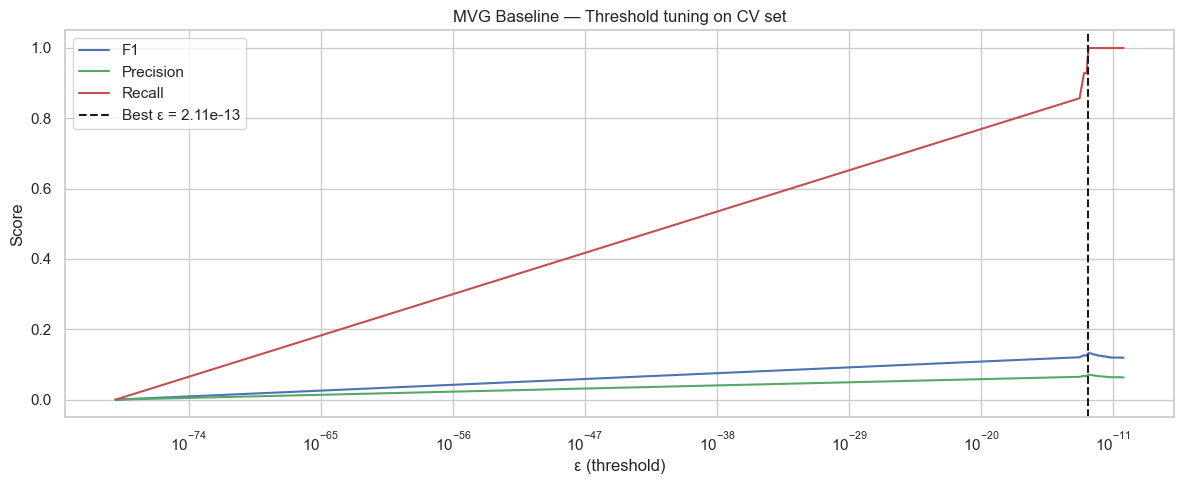

In [10]:
# Score CV set and tune threshold ε
p_cv_base = multivariate_gaussian_pdf(X_cross_val, mu_base, sigma_base)
best_eps_base, best_f1_cv_base = tune_threshold(p_cv_base, y_cross_val,
                                                 higher_is_anomalous=False)

print(f"Best ε (CV) : {best_eps_base:.4e}")
print(f"Best F1 (CV): {best_f1_cv_base:.4f}")

# Plot F1/Precision/Recall vs ε
thresholds = np.linspace(np.min(p_cv_base), np.max(p_cv_base), 1000)
f1s, precs, recs = [], [], []
for thr in thresholds:
    preds = (p_cv_base < thr).astype(int)
    precs.append(precision_score(y_cross_val, preds, zero_division=0))
    recs.append(recall_score(y_cross_val, preds, zero_division=0))
    f1s.append(f1_score(y_cross_val, preds, zero_division=0))

plt.figure(figsize=(12, 5))
plt.plot(thresholds, f1s,   'b-', label='F1')
plt.plot(thresholds, precs, 'g-', label='Precision')
plt.plot(thresholds, recs,  'r-', label='Recall')
plt.axvline(best_eps_base, color='k', linestyle='--',
            label=f'Best ε = {best_eps_base:.2e}')
plt.xscale('log')
plt.xlabel('ε (threshold)')
plt.ylabel('Score')
plt.title('MVG Baseline — Threshold tuning on CV set')
plt.legend()
plt.tight_layout()
plt.show()


  MVG Baseline
  Precision : 0.1552
  Recall    : 0.9310
  F1 Score  : 0.2660
  AUC       : 0.7768


/Users/simonezani/Documents/github/fintech-group-work/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2406: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/simonezani/Documents/github/fintech-group-work/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2406: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/simonezani/Documents/github/fintech-group-work/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2406: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


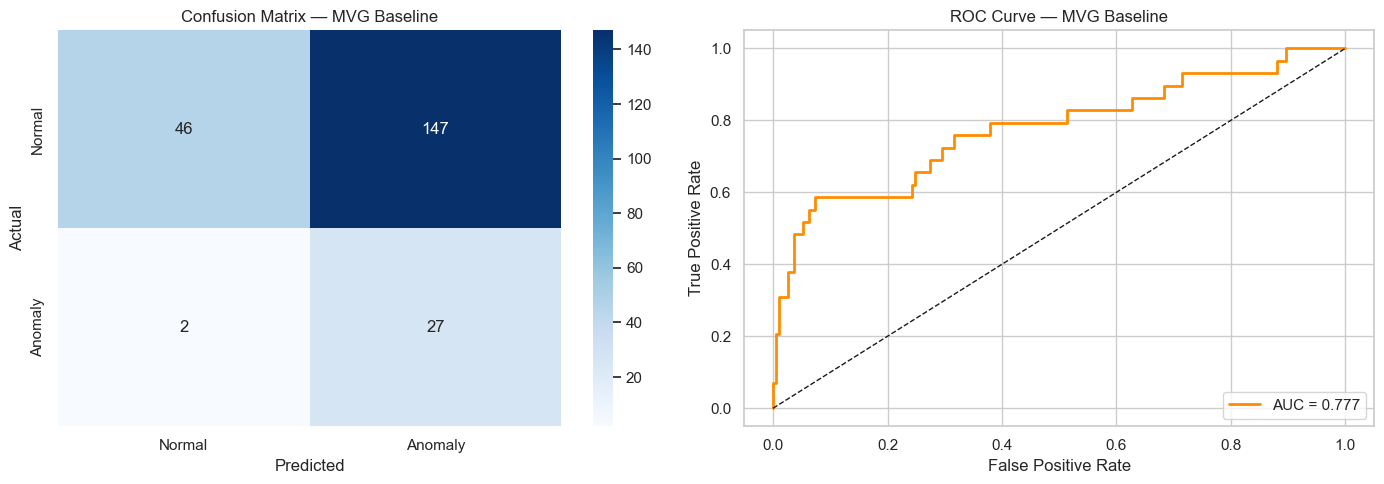

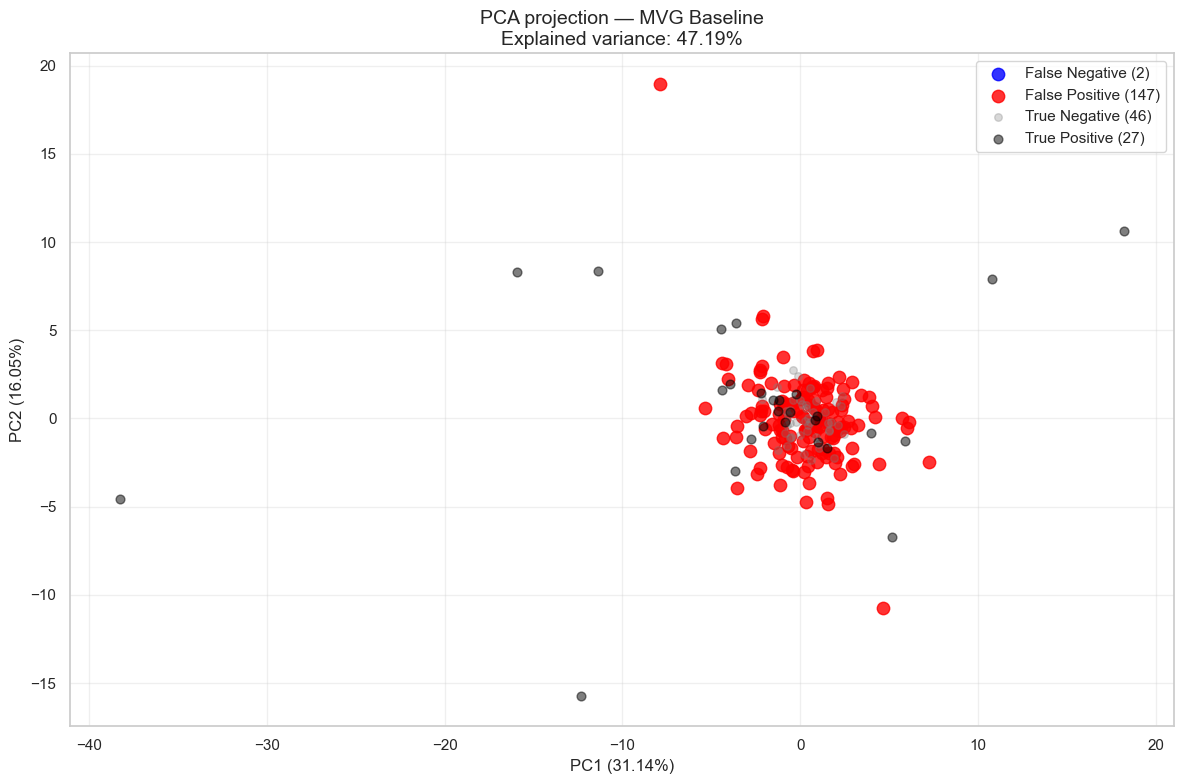

In [11]:
# Evaluate on test set
p_test_base  = multivariate_gaussian_pdf(X_test, mu_base, sigma_base)
pred_base    = (p_test_base < best_eps_base).astype(int)

evaluate_model(y_test, pred_base, -p_test_base, 'MVG Baseline')
visualize_pca(X_test, y_test, pred_base, 'MVG Baseline')

---

# 📊 Model 2 — MVG + Ledoit-Wolf Covariance

The standard sample covariance $\hat{\Sigma}$ is **noisy** when the number of features $p$ is large relative to the sample size $n$.
With ~40 features and a limited number of normal training observations, this is exactly our situation.

**Ledoit-Wolf** applies an optimal linear shrinkage: it pulls the sample covariance towards a scaled identity matrix.

$$\hat{\Sigma}_{LW} = (1 - \alpha)\,\hat{\Sigma}_{sample} + \alpha\,\mu_I\,I$$

The shrinkage coefficient $\alpha$ is estimated analytically — no cross-validation needed.

> 📎 Ref: Ledoit & Wolf (2004). *A well-conditioned estimator for large-dimensional covariance matrices.*

<br>

In [12]:
# Fit Ledoit-Wolf estimator on normal training data
lw = LedoitWolf().fit(X_train)

mu_lw    = np.mean(X_train, axis=0)   # same mean as baseline
sigma_lw = lw.covariance_

print(f"Ledoit-Wolf shrinkage coefficient α : {lw.shrinkage_:.4f}")
print(f"  (α = 0 → pure sample cov, α = 1 → scaled identity)")

Ledoit-Wolf shrinkage coefficient α : 0.0417
  (α = 0 → pure sample cov, α = 1 → scaled identity)


/Users/simonezani/Documents/github/fintech-group-work/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2406: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/simonezani/Documents/github/fintech-group-work/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2406: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/simonezani/Documents/github/fintech-group-work/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2406: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)



  MVG Ledoit-Wolf
  Precision : 0.1552
  Recall    : 0.9310
  F1 Score  : 0.2660
  AUC       : 0.7833


/Users/simonezani/Documents/github/fintech-group-work/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2406: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/simonezani/Documents/github/fintech-group-work/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2406: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/simonezani/Documents/github/fintech-group-work/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2406: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


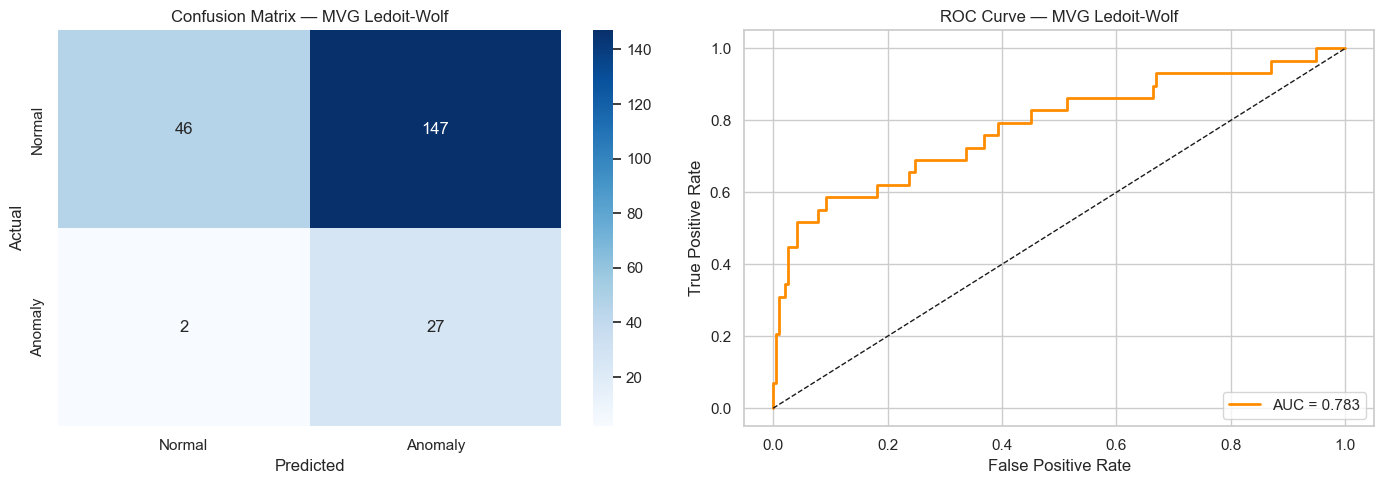

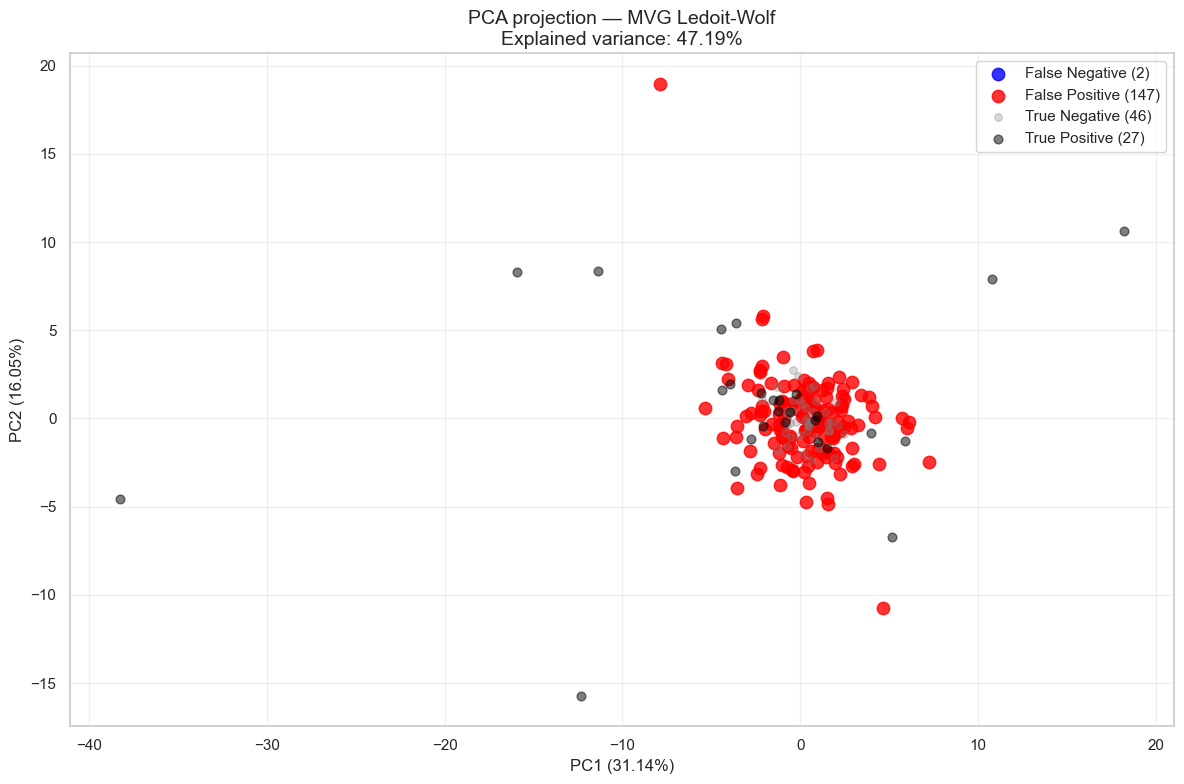

In [13]:
# Score CV set and tune threshold
p_cv_lw = multivariate_gaussian_pdf(X_cross_val, mu_lw, sigma_lw)
best_eps_lw, _ = tune_threshold(p_cv_lw, y_cross_val, higher_is_anomalous=False)

# Evaluate on test set
p_test_lw = multivariate_gaussian_pdf(X_test, mu_lw, sigma_lw)
pred_lw   = (p_test_lw < best_eps_lw).astype(int)

evaluate_model(y_test, pred_lw, -p_test_lw, 'MVG Ledoit-Wolf')
visualize_pca(X_test, y_test, pred_lw, 'MVG Ledoit-Wolf')

In [14]:
# Compare condition numbers: sample cov vs Ledoit-Wolf
cond_sample = np.linalg.cond(sigma_base)
cond_lw     = np.linalg.cond(sigma_lw)

print(f"Condition number — Sample covariance : {cond_sample:.2e}")
print(f"Condition number — Ledoit-Wolf       : {cond_lw:.2e}")
print(f"\nA lower condition number → better numerical stability → more reliable PDF values.")

Condition number — Sample covariance : 1.13e+03
Condition number — Ledoit-Wolf       : 1.93e+02

A lower condition number → better numerical stability → more reliable PDF values.


---

# 📊 Model 3 — Elliptic Envelope

The **Elliptic Envelope** (`sklearn.covariance.EllipticEnvelope`) fits a robust Gaussian distribution
to the data and flags points that fall outside a Mahalanobis-distance ellipse.

Key difference from the baseline MVG:
- It uses a **robust covariance estimator** (Minimum Covariance Determinant — MCD) that is less sensitive to outliers in the training data.
- The decision boundary is set directly via the `contamination` parameter — no manual threshold sweep needed.

> 📎 The `contamination` parameter (fraction of anomalies expected) is estimated from the CV set.

<br>

/Users/simonezani/Documents/github/fintech-group-work/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2349: RuntimeWarning: divide by zero encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/simonezani/Documents/github/fintech-group-work/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2349: RuntimeWarning: overflow encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/simonezani/Documents/github/fintech-group-work/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2349: RuntimeWarning: invalid value encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/simonezani/Documents/github/fintech-group-work/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2349: RuntimeWarning: divide by zero encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/simonezani/Documents/github/fintech-group-work/.venv/lib

Contamination rate (from CV set): 0.0631

  Elliptic Envelope
  Precision : 0.7500
  Recall    : 0.3103
  F1 Score  : 0.4390
  AUC       : 0.7629


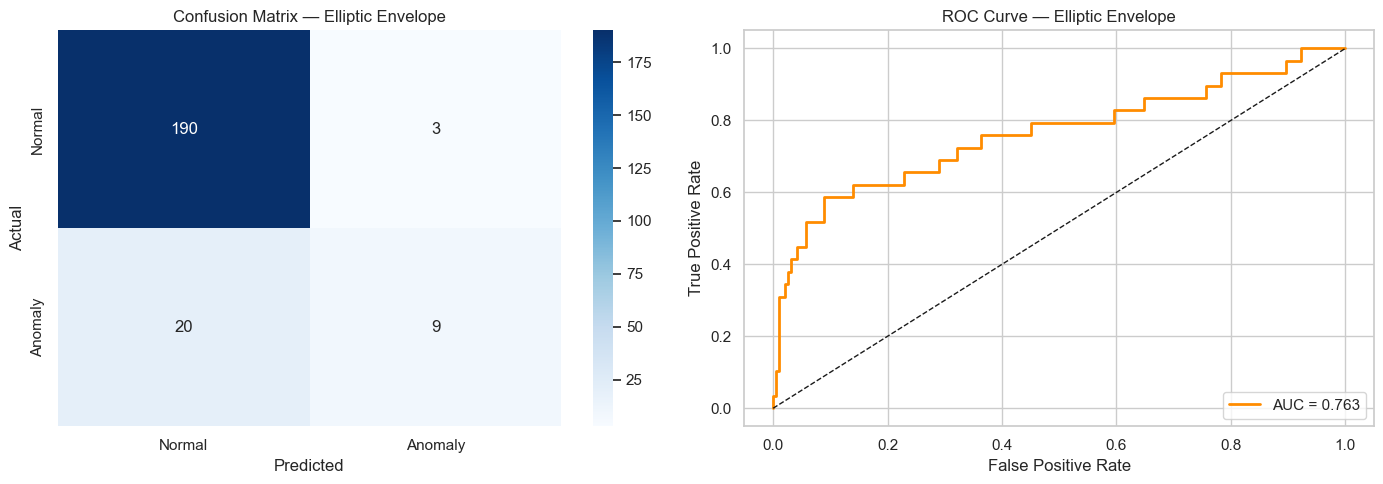

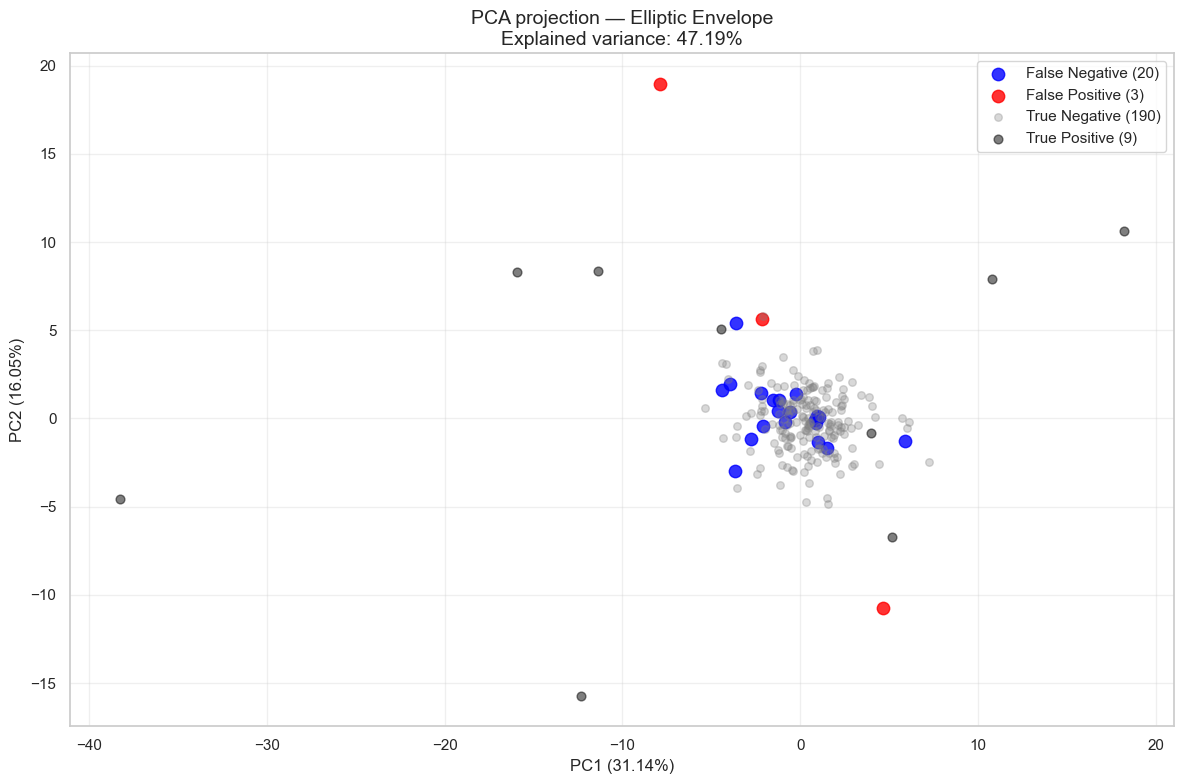

In [15]:
# Estimate contamination from CV set (fraction of anomalies)
contamination = float(np.mean(y_cross_val))
contamination = np.clip(contamination, 0.01, 0.49)  # keep in valid range
print(f"Contamination rate (from CV set): {contamination:.4f}")

# Fit Elliptic Envelope on normal training data
ee = EllipticEnvelope(contamination=contamination, random_state=42, support_fraction=0.9)
ee.fit(X_train)

# Predict on test set: EllipticEnvelope returns +1 (inlier) / -1 (outlier)
ee_raw  = ee.predict(X_test)
pred_ee = (ee_raw == -1).astype(int)

# Anomaly score = negative Mahalanobis distance (higher → more anomalous)
score_ee = -ee.score_samples(X_test)

evaluate_model(y_test, pred_ee, score_ee, 'Elliptic Envelope')
visualize_pca(X_test, y_test, pred_ee, 'Elliptic Envelope')

---

# 📊 Model 4 — MVG CDF-based Scoring

The standard MVG uses the **PDF** as anomaly score: we flag a point if its probability density is low.

A subtlety: the PDF is symmetric — it assigns a low value **both** to
catastrophically bad markets **and** to unusually good ones.
In practice, only the bad ones are risk-off events.

An alternative is to use the **CDF**:

$$\text{score}(x) = \Phi\left(\frac{x - \mu}{\sigma}\right)$$

We compute the **joint probability** $P(X_1 \leq x_1, X_2 \leq x_2, \ldots)$ and flag points where this value is **very low** (i.e. the observation falls deep in the left tail of the joint distribution).

> This is equivalent to checking whether a week is "anomalously bad" across all dimensions simultaneously.

<br>


  MVG CDF-based
  Precision : 0.1412
  Recall    : 0.8621
  F1 Score  : 0.2427
  AUC       : 0.7659


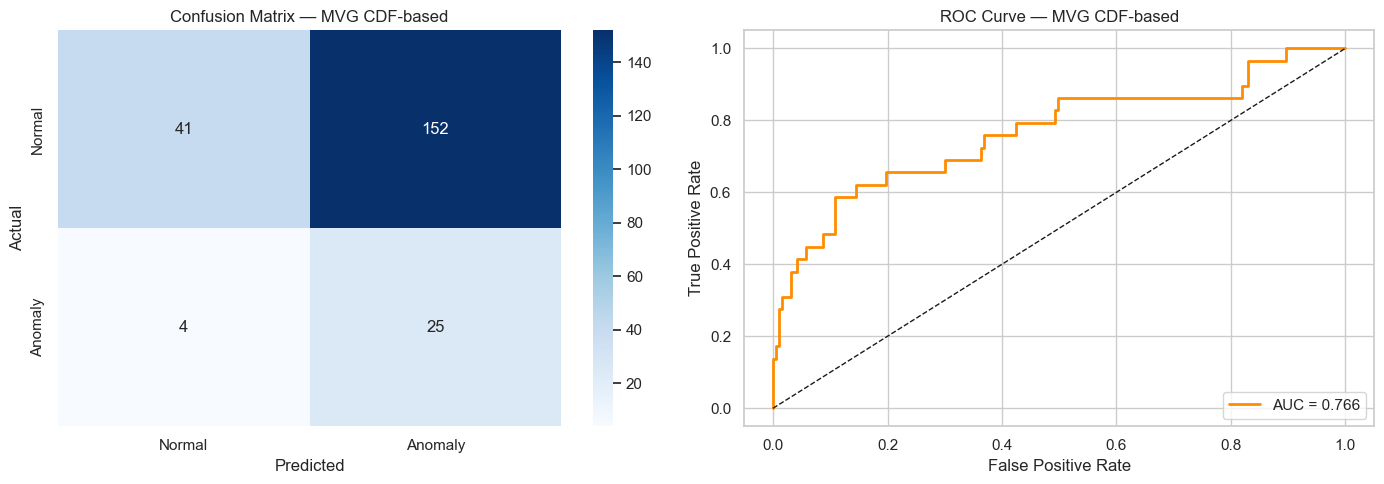

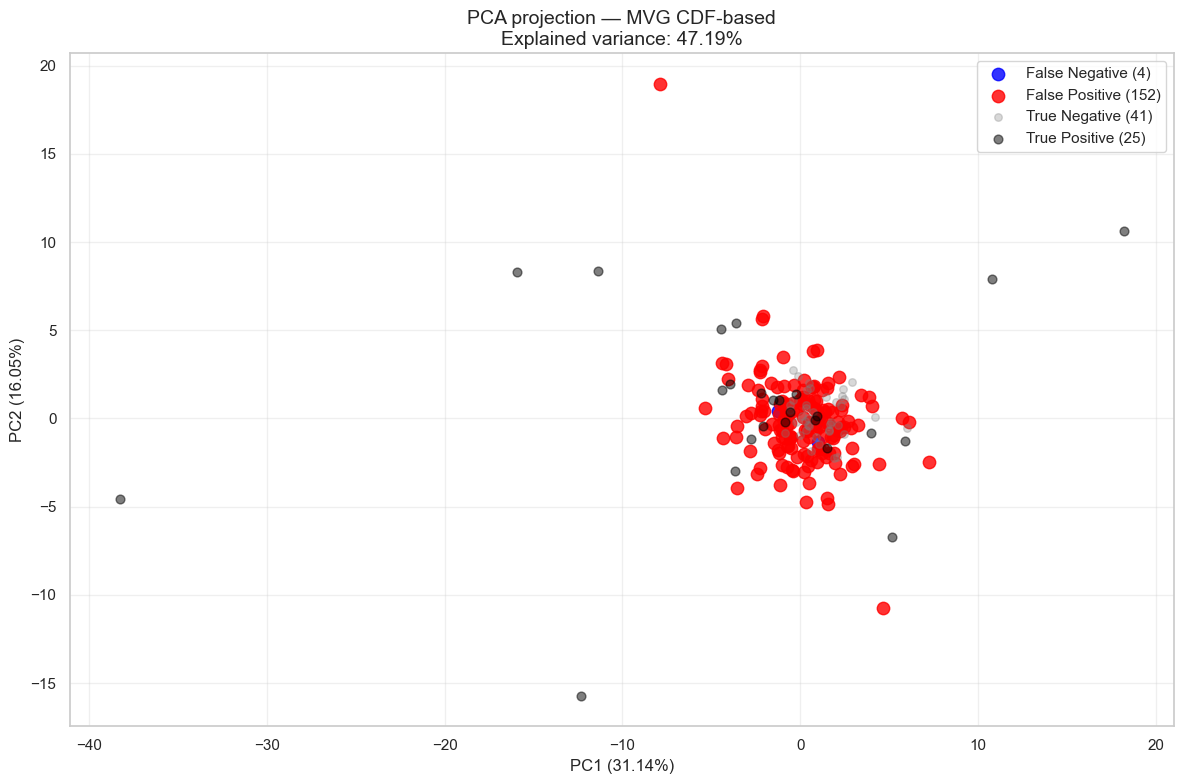

In [16]:
def mvg_cdf_score(X, mu, sigma):
    """
    CDF-based anomaly score for the Multivariate Gaussian.
    Returns the joint CDF value P(X1<=x1, X2<=x2, ...) for each observation.
    Low values → observation is simultaneously low across all dimensions → anomalous.

    We use the multivariate normal CDF evaluated at each point.
    Since scipy.stats.multivariate_normal.cdf can be slow for large dim,
    we use the product of marginal CDFs as an approximation (assumes independence
    after whitening with the Cholesky factor).
    """
    n_features = mu.shape[0]
    sigma_reg  = sigma + np.eye(n_features) * 1e-8

    # Whiten: transform X so that the covariance becomes identity
    try:
        L = np.linalg.cholesky(sigma_reg)
    except np.linalg.LinAlgError:
        L = np.linalg.cholesky(sigma_reg + np.eye(n_features) * 1e-6)

    X_centered  = X - mu
    X_whitened  = np.linalg.solve(L, X_centered.T).T  # shape (N, p)

    # After whitening, each dimension is ~ N(0,1)
    # Joint CDF ≈ product of marginal CDFs (exact if truly decorrelated)
    marginal_cdfs = stats.norm.cdf(X_whitened)          # shape (N, p)
    joint_cdf     = np.prod(marginal_cdfs, axis=1)      # shape (N,)

    return joint_cdf


# Score CV set and tune threshold (low CDF → anomalous)
cdf_cv     = mvg_cdf_score(X_cross_val, mu_base, sigma_base)
best_eps_cdf, _ = tune_threshold(cdf_cv, y_cross_val, higher_is_anomalous=False)

# Score test set
cdf_test   = mvg_cdf_score(X_test, mu_base, sigma_base)
pred_cdf   = (cdf_test < best_eps_cdf).astype(int)

evaluate_model(y_test, pred_cdf, -cdf_test, 'MVG CDF-based')
visualize_pca(X_test, y_test, pred_cdf, 'MVG CDF-based')

---

# 📊 Model 5 — MVG Asymmetric (Discriminating Variable)

Both the PDF and CDF models treat very good and very bad markets symmetrically.
But a **risk-off event** is by definition a period of **losses**, not of extreme gains.

We add a **financial override rule**:

> If the discriminating variable (e.g. log-return of MXUS) is **above a threshold K**,
> the market cannot be in a risk-off state, regardless of what the MVG says.

$$\hat{y}_i = \begin{cases} 0 & \text{if discriminant}_i > K \\ 1 & \text{if } p(x_i) < \varepsilon \text{ and discriminant}_i \leq K \end{cases}$$

Both $\varepsilon$ and $K$ are tuned jointly on the CV set by maximising F1.

> 💡 This reflects the financial intuition: we are only interested in flagging *downside* anomalies.

<br>

In [17]:
# Identify the discriminating feature index
# We use the log-return of MXUS (US equity) as the discriminating variable
DISCRIMINANT_COL = 'MXUS'

if DISCRIMINANT_COL in stationary_df.columns:
    disc_idx = stationary_df.columns.get_loc(DISCRIMINANT_COL)
    print(f"Discriminating variable : {DISCRIMINANT_COL} (index {disc_idx})")
else:
    # Fallback: use VIX (high VIX → risk-off; we want to flag low equity / high VIX)
    DISCRIMINANT_COL = 'VIX'
    disc_idx = stationary_df.columns.get_loc(DISCRIMINANT_COL)
    print(f"MXUS not found — using {DISCRIMINANT_COL} (index {disc_idx}) as fallback")

Discriminating variable : MXUS (index 20)


In [18]:
# Joint grid search over (ε, K) on the CV set
p_cv_asym = multivariate_gaussian_pdf(X_cross_val, mu_base, sigma_base)

eps_candidates = np.linspace(np.min(p_cv_asym), np.max(p_cv_asym), 200)
k_candidates   = np.percentile(X_cross_val[:, disc_idx],
                               np.arange(10, 91, 10))  # 10th–90th percentile

best_f1_asym   = 0.0
best_eps_asym  = eps_candidates[0]
best_k_asym    = k_candidates[0]

for eps in eps_candidates:
    for K in k_candidates:
        preds = np.zeros(len(y_cross_val), dtype=int)
        mvg_flag    = (p_cv_asym < eps)                        # MVG says anomalous
        not_bullish = (X_cross_val[:, disc_idx] <= K)          # market is NOT above K
        preds[mvg_flag & not_bullish] = 1

        f1 = f1_score(y_cross_val, preds, zero_division=0)
        if f1 > best_f1_asym:
            best_f1_asym, best_eps_asym, best_k_asym = f1, eps, K

print(f"Best F1 on CV : {best_f1_asym:.4f}")
print(f"Best ε        : {best_eps_asym:.4e}")
print(f"Best K        : {best_k_asym:.4f}  ({DISCRIMINANT_COL} log-return threshold)")

/Users/simonezani/Documents/github/fintech-group-work/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2406: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/simonezani/Documents/github/fintech-group-work/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2406: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/simonezani/Documents/github/fintech-group-work/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2406: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


Best F1 on CV : 0.2162
Best ε        : 2.6466e-13
Best K        : -1.2228  (MXUS log-return threshold)



  MVG Asymmetric
  Precision : 0.6087
  Recall    : 0.4828
  F1 Score  : 0.5385
  AUC       : 0.2868


/Users/simonezani/Documents/github/fintech-group-work/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2406: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/simonezani/Documents/github/fintech-group-work/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2406: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/simonezani/Documents/github/fintech-group-work/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2406: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


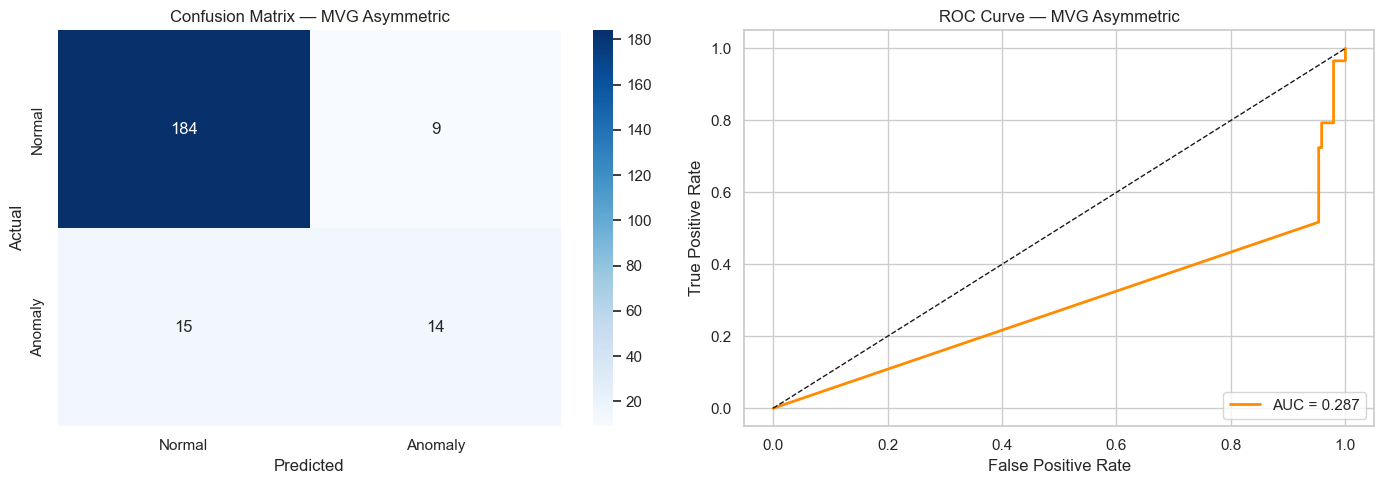

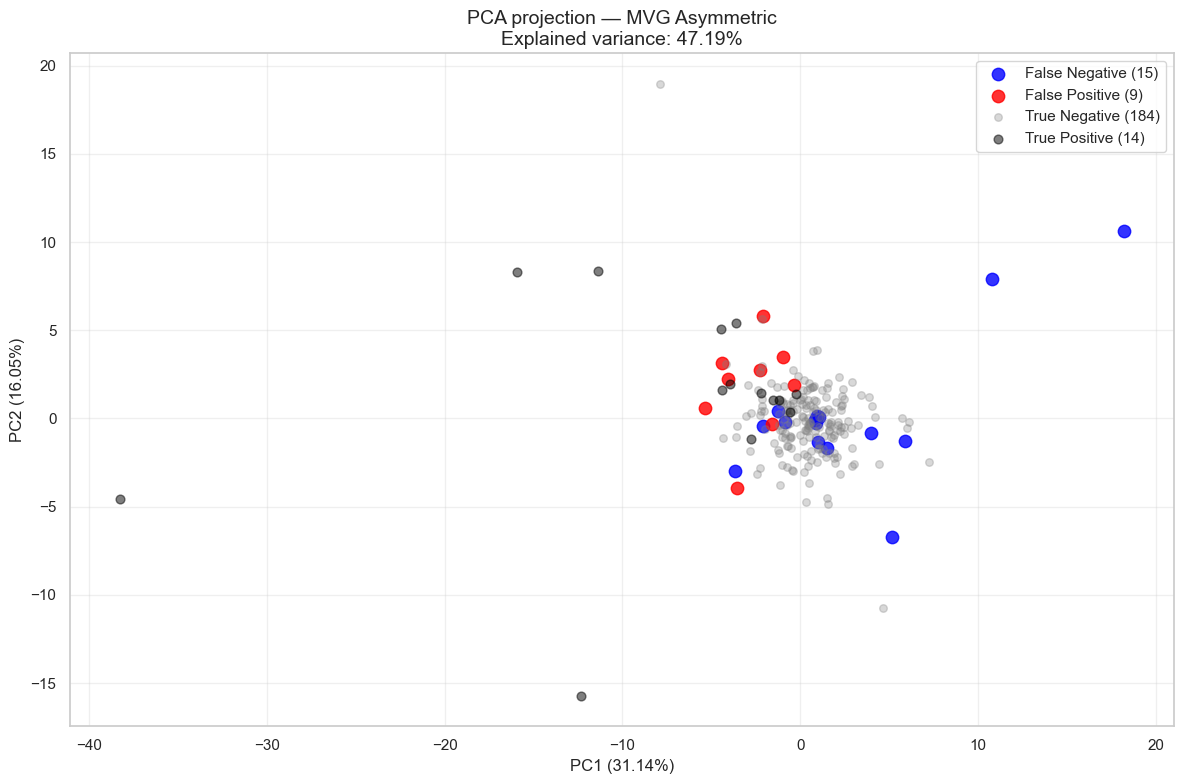

In [19]:
# Evaluate on test set
p_test_asym = multivariate_gaussian_pdf(X_test, mu_base, sigma_base)

pred_asym = np.zeros(len(y_test), dtype=int)
mvg_flag_test    = (p_test_asym < best_eps_asym)
not_bullish_test = (X_test[:, disc_idx] <= best_k_asym)
pred_asym[mvg_flag_test & not_bullish_test] = 1

# Score: negative PDF * asymmetry mask (0 if market was bullish)
score_asym = -p_test_asym * (X_test[:, disc_idx] <= best_k_asym).astype(float)

evaluate_model(y_test, pred_asym, score_asym, 'MVG Asymmetric')
visualize_pca(X_test, y_test, pred_asym, 'MVG Asymmetric')

---

# 🔭 Dimensionality Reduction Visualizations

Beyond PCA, we explore **non-linear** projection techniques to understand the structure of the data and the quality of our best model's predictions.

- **t-SNE** — preserves local neighborhoods; good at revealing clusters.
- **PACMAP** — preserves both local and global structure; faster than t-SNE.
- **Spectral Embedding** — graph-based; emphasizes manifold structure.

> 📌 Key observation from the professor: anomalies do **not** cluster at the periphery of these projections — they are spread throughout the space. This highlights the limits of density-based models.

<br>

In [20]:
def plot_embedding(X_2d, y_true, y_pred, method_name, dim1='Dim 1', dim2='Dim 2'):
    """Generic scatter plot for any 2D embedding."""
    df_plot = pd.DataFrame(X_2d, columns=[dim1, dim2])
    df_plot['Category'] = 'Unknown'
    df_plot.loc[(y_true == 0) & (y_pred == 0), 'Category'] = 'True Negative'
    df_plot.loc[(y_true == 0) & (y_pred == 1), 'Category'] = 'False Positive'
    df_plot.loc[(y_true == 1) & (y_pred == 0), 'Category'] = 'False Negative'
    df_plot.loc[(y_true == 1) & (y_pred == 1), 'Category'] = 'True Positive'

    plt.figure(figsize=(12, 8))
    for cat, grp in df_plot.groupby('Category'):
        plt.scatter(grp[dim1], grp[dim2],
                    color=COLORS[cat], alpha=ALPHAS[cat], s=SIZES[cat],
                    label=f"{cat} ({len(grp)})")
    plt.title(f'{method_name} projection', fontsize=14)
    plt.xlabel(dim1)
    plt.ylabel(dim2)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# Use MVG Baseline predictions for the visualizations
best_pred_for_viz = pred_base   # change to pred_lw / pred_ee etc. if desired

Running t-SNE (this may take ~1 min on large datasets)...


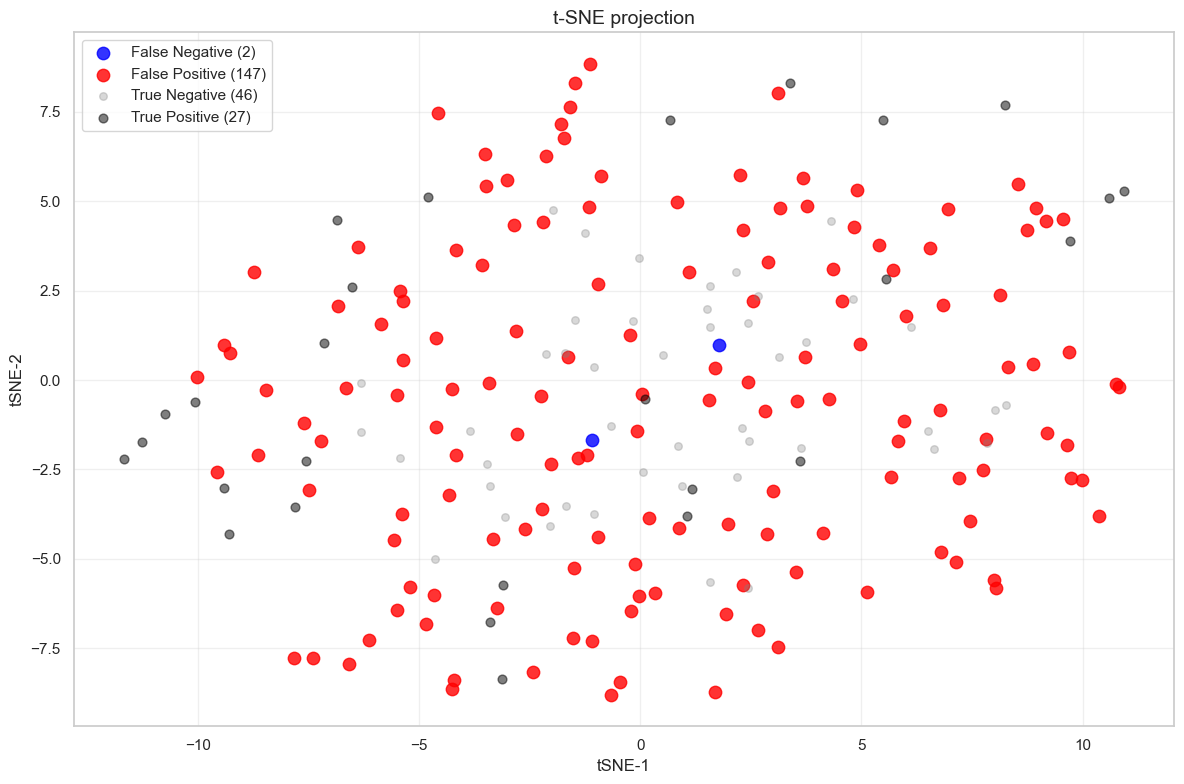

In [21]:
# ── t-SNE ──────────────────────────────────────────────────────────────────
print("Running t-SNE (this may take ~1 min on large datasets)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_test)

plot_embedding(X_tsne, y_test, best_pred_for_viz, 't-SNE', 'tSNE-1', 'tSNE-2')

Running Spectral Embedding...


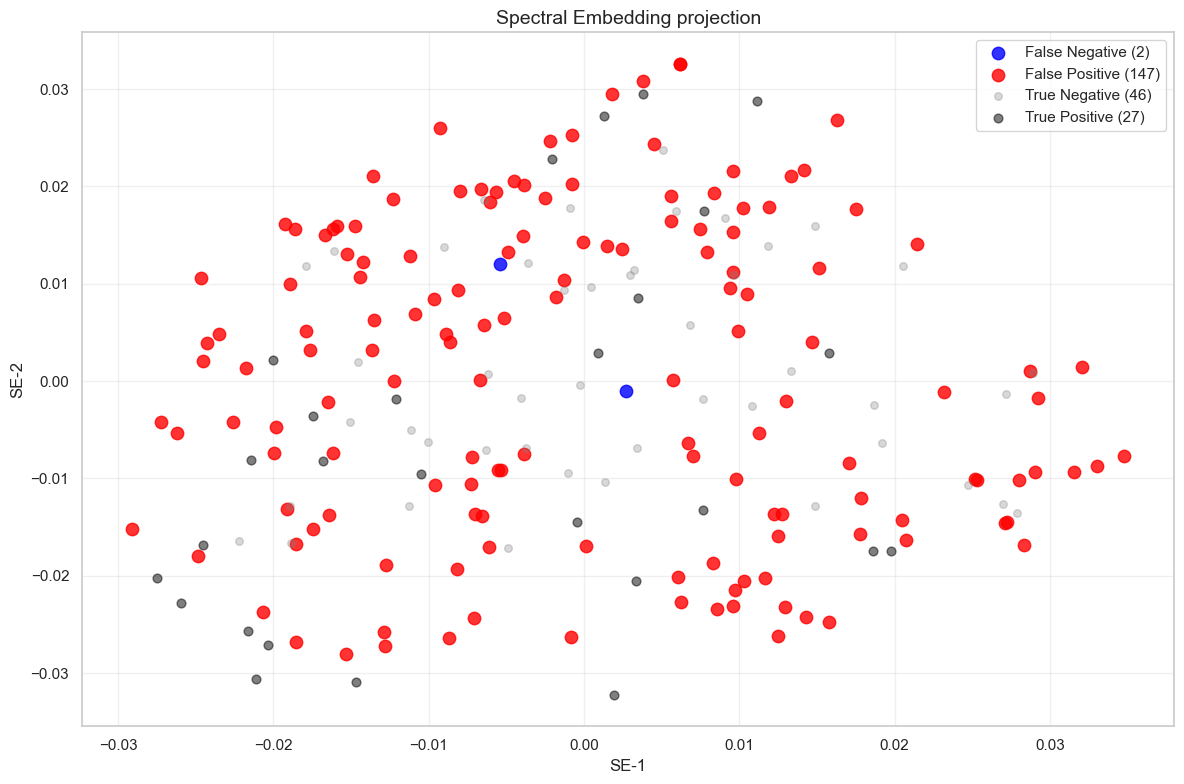

In [22]:
# ── Spectral Embedding ─────────────────────────────────────────────────────
print("Running Spectral Embedding...")
se = SpectralEmbedding(n_components=2, random_state=42)
X_se = se.fit_transform(X_test)

plot_embedding(X_se, y_test, best_pred_for_viz, 'Spectral Embedding', 'SE-1', 'SE-2')

In [23]:
# ── PACMAP ─────────────────────────────────────────────────────────────────
if pacmap_available:
    print("Running PACMAP...")
    pm = pacmap.PaCMAP(n_components=2, random_state=42)
    X_pm = pm.fit_transform(X_test)
    plot_embedding(X_pm, y_test, best_pred_for_viz, 'PACMAP', 'PM-1', 'PM-2')
else:
    print("PACMAP not installed — skipping. Install with: pip install pacmap")

PACMAP not installed — skipping. Install with: pip install pacmap


---

# 🧪 Synthetic Data Experiments

Before concluding, we run controlled experiments with **synthetic data** to understand how the MVG detector behaves as we change the Data Generating Process (DGP).

We vary:
1. **Separation** between normal and anomalous distributions.
2. **Dimensionality** (number of features).
3. **Anomaly fraction**.

This gives intuition about when the model works well and when it fails — and is directly comparable to the real-data results.

<br>

In [24]:
def run_synthetic_experiment(n_normal=10000, n_anomaly=100, n_dim=2,
                              separation=5.0, random_state=42):
    """
    Generate synthetic data and evaluate MVG baseline.
    Returns (precision, recall, f1, auc).
    """
    rng = np.random.default_rng(random_state)

    mu_normal  = np.ones(n_dim)
    mu_anomaly = -separation * np.ones(n_dim)
    cov_normal  = np.eye(n_dim) * 1.5
    cov_anomaly = np.eye(n_dim) * 3.0

    r1 = rng.multivariate_normal(mu_normal,  cov_normal,  n_normal)
    r2 = rng.multivariate_normal(mu_anomaly, cov_anomaly, n_anomaly)

    X_all = np.vstack([r1, r2])
    y_all = np.hstack([np.zeros(n_normal), np.ones(n_anomaly)])
    X_all, y_all = shuffle(X_all, y_all, random_state=random_state)

    X_n = X_all[y_all == 0]
    X_a = X_all[y_all == 1]
    nn, na = len(X_n), len(X_a)

    ts  = int(0.6 * nn)
    cvs = int(0.2 * nn)

    Xtr  = X_n[:ts]
    Xcv  = np.vstack([X_n[ts:ts+cvs], X_a[:na//2]])
    ycv  = np.hstack([np.zeros(cvs), np.ones(na//2)])
    Xte  = np.vstack([X_n[ts+cvs:], X_a[na//2:]])
    yte  = np.hstack([np.zeros(len(X_n)-ts-cvs), np.ones(na-na//2)])

    sc = StandardScaler().fit(Xtr)
    Xtr, Xcv, Xte = sc.transform(Xtr), sc.transform(Xcv), sc.transform(Xte)

    mu_s, sg_s = np.mean(Xtr, axis=0), np.cov(Xtr, rowvar=False)
    if n_dim == 1:
        sg_s = np.array([[sg_s]])

    p_cv  = multivariate_gaussian_pdf(Xcv, mu_s, sg_s)
    thr, _ = tune_threshold(p_cv, ycv, higher_is_anomalous=False)
    p_te   = multivariate_gaussian_pdf(Xte, mu_s, sg_s)
    preds  = (p_te < thr).astype(int)

    prec = precision_score(yte, preds, zero_division=0)
    rec  = recall_score(yte, preds, zero_division=0)
    f1   = f1_score(yte, preds, zero_division=0)
    fpr, tpr, _ = roc_curve(yte, -p_te)
    roc_auc = auc(fpr, tpr)

    return prec, rec, f1, roc_auc


print("Synthetic experiment function defined.")

Synthetic experiment function defined.


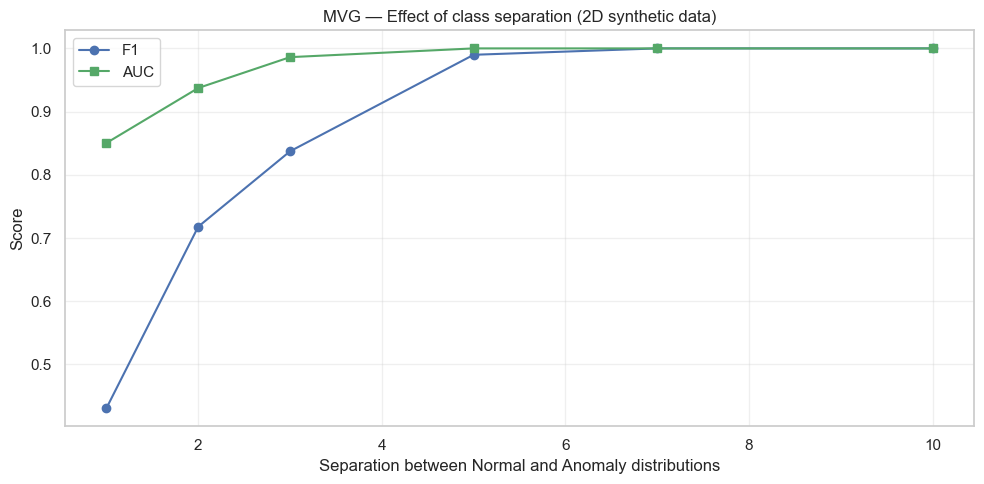

,Separation,Precision,Recall,F1,AUC
0,1,0.933333,0.28,0.430769,0.85036
1,2,1.000000,0.56,0.717949,0.93732
2,3,1.000000,0.72,0.837209,0.98617
3,5,1.000000,0.98,0.989899,0.99999
4,7,1.000000,1.00,1.000000,1.00000
5,10,1.000000,1.00,1.000000,1.00000


In [25]:
# Experiment 1 — Effect of separation distance
separations = [1, 2, 3, 5, 7, 10]
sep_results = []

for sep in separations:
    p, r, f, au = run_synthetic_experiment(separation=sep, n_dim=2)
    sep_results.append({'Separation': sep, 'Precision': p, 'Recall': r, 'F1': f, 'AUC': au})

sep_df = pd.DataFrame(sep_results)

plt.figure(figsize=(10, 5))
plt.plot(sep_df['Separation'], sep_df['F1'],  'b-o', label='F1')
plt.plot(sep_df['Separation'], sep_df['AUC'], 'g-s', label='AUC')
plt.xlabel('Separation between Normal and Anomaly distributions')
plt.ylabel('Score')
plt.title('MVG — Effect of class separation (2D synthetic data)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

display(sep_df)

/Users/simonezani/Documents/github/fintech-group-work/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2406: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/simonezani/Documents/github/fintech-group-work/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2406: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/simonezani/Documents/github/fintech-group-work/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2406: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/simonezani/Documents/github/fintech-group-work/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2406: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/simonezani/Documents/github/fintech-group-work/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2406: RuntimeWarning: over

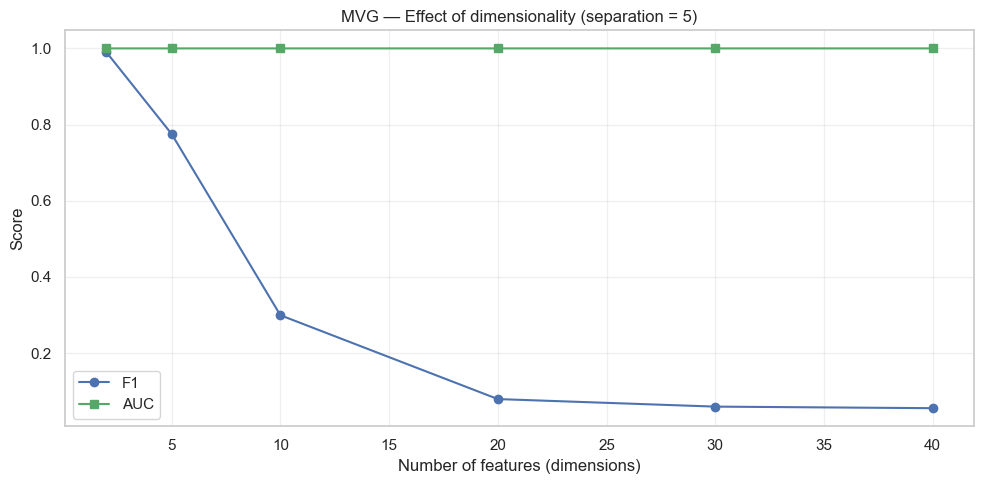

,Dimensions,Precision,Recall,F1,AUC
0,2,1.000000,0.98,0.989899,0.99999
1,5,0.632911,1.00,0.775194,1.00000
2,10,0.176056,1.00,0.299401,1.00000
3,20,0.041254,1.00,0.079239,1.00000
4,30,0.030618,1.00,0.059418,1.00000
5,40,0.028441,1.00,0.055310,1.00000


In [26]:
# Experiment 2 — Effect of dimensionality
dims = [2, 5, 10, 20, 30, 40]
dim_results = []

for d in dims:
    p, r, f, au = run_synthetic_experiment(n_dim=d, separation=5.0)
    dim_results.append({'Dimensions': d, 'Precision': p, 'Recall': r, 'F1': f, 'AUC': au})

dim_df = pd.DataFrame(dim_results)

plt.figure(figsize=(10, 5))
plt.plot(dim_df['Dimensions'], dim_df['F1'],  'b-o', label='F1')
plt.plot(dim_df['Dimensions'], dim_df['AUC'], 'g-s', label='AUC')
plt.xlabel('Number of features (dimensions)')
plt.ylabel('Score')
plt.title('MVG — Effect of dimensionality (separation = 5)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

display(dim_df)

---

# 🔍 Feature Importance via Permutation

We estimate which features are **most important** to the MVG detector by **zeroing out** one feature at a time
and measuring how much the **log-likelihood** changes on the test set.

$$\text{Importance}_j = \overline{\log p(x)} - \overline{\log p(x^{(j)})}$$

where $x^{(j)}$ is the observation with feature $j$ set to its mean (i.e. zero after standardisation).

A large positive value means the model relies heavily on feature $j$ to characterise normality.

<br>

/Users/simonezani/Documents/github/fintech-group-work/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2406: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/simonezani/Documents/github/fintech-group-work/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2406: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/simonezani/Documents/github/fintech-group-work/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2406: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)
/var/folders/1h/rgxjfdl160ggs7g4d3qrs4100000gn/T/ipykernel_85398/2002674179.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top20, palette='Blues_r')


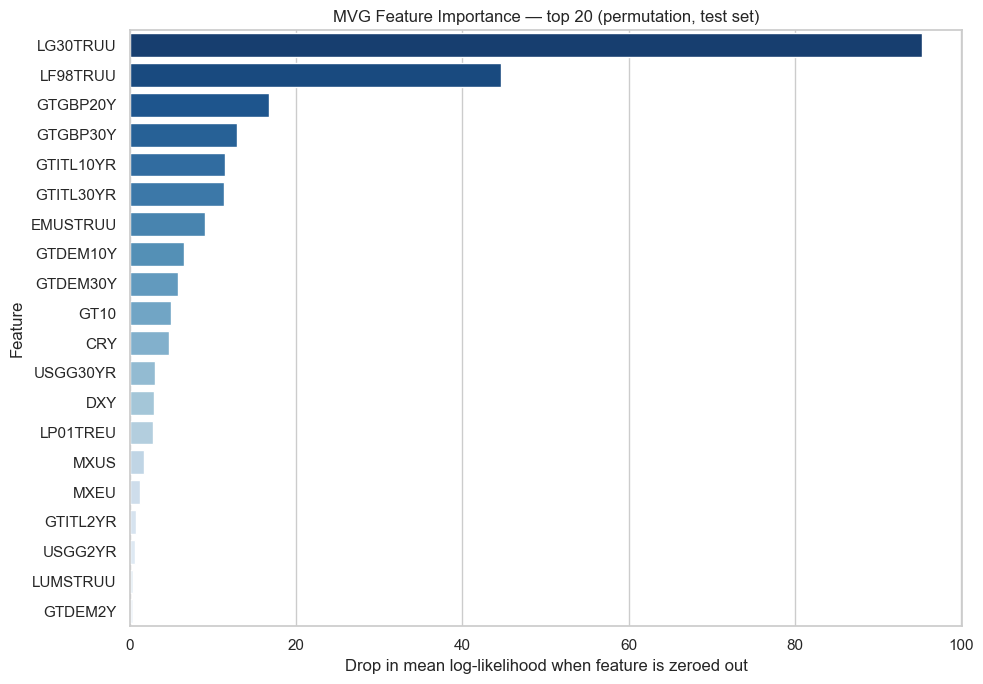


Top 10 most important features:


,Feature,Importance
9,LG30TRUU,95.330863
8,LF98TRUU,44.667763
28,GTGBP20Y,16.739517
30,GTGBP30Y,12.914373
31,GTITL10YR,11.474758
33,GTITL30YR,11.309144
4,EMUSTRUU,9.035245
25,GTDEM10Y,6.523775
27,GTDEM30Y,5.733904
24,GT10,4.953022


In [27]:
def mvg_feature_importance(X, mu, sigma, feature_names):
    """
    Compute feature importance for the MVG detector.
    Measures the drop in mean log-likelihood when each feature is zeroed out.
    """
    n_features = X.shape[1]
    sigma_reg  = sigma + np.eye(n_features) * 1e-8

    # Baseline log-likelihood
    try:
        inv = np.linalg.inv(sigma_reg)
        det = np.linalg.det(sigma_reg)
    except np.linalg.LinAlgError:
        inv = np.linalg.pinv(sigma_reg)
        det = max(np.linalg.det(sigma_reg), 1e-10)

    def log_likelihood(X_):
        ll = np.zeros(X_.shape[0])
        for i in range(X_.shape[0]):
            xm = X_[i] - mu
            ll[i] = -0.5 * (xm @ inv @ xm) - 0.5 * np.log(max(det, 1e-300))
        return ll

    baseline_ll = np.mean(log_likelihood(X))
    importance  = []

    for j in range(n_features):
        X_masked    = X.copy()
        X_masked[:, j] = 0.0          # zero-out = set to mean (after standardisation)
        masked_ll   = np.mean(log_likelihood(X_masked))
        importance.append(baseline_ll - masked_ll)

    imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
    return imp_df.sort_values('Importance', ascending=False)


feature_names = stationary_df.columns.tolist()
imp_df = mvg_feature_importance(X_test, mu_base, sigma_base, feature_names)

# Plot top 20 features
top20 = imp_df.head(20)
plt.figure(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature', data=top20, palette='Blues_r')
plt.title('MVG Feature Importance — top 20 (permutation, test set)')
plt.xlabel('Drop in mean log-likelihood when feature is zeroed out')
plt.tight_layout()
plt.show()

print("\nTop 10 most important features:")
display(imp_df.head(10))

---

# 📊 Model 6 — Multivariate Student-t Distribution

The Gaussian assumption is the most criticised hypothesis in all of quantitative finance.
Financial returns are **leptokurtic**: they have **fatter tails** than the normal distribution,
meaning extreme events are far more frequent than the MVG predicts.

The **Multivariate Student-t** is the natural fix:

$$p(x;\mu,\Sigma,\nu) \propto \left(1 + \frac{(x-\mu)^T\Sigma^{-1}(x-\mu)}{\nu}\right)^{-\frac{\nu+d}{2}}$$

- $\nu$ = degrees of freedom — controls tail thickness ($\nu \to \infty$ recovers the Gaussian).
- Small $\nu$ (e.g. 3–5) → very heavy tails → model is less surprised by extreme moves.
- We select $\nu$ by maximising F1 on the CV set.

> 📎 Used extensively in financial econometrics: GARCH-t, VaR/CVaR models, copula fitting.

<br>

In [28]:
from scipy.stats import multivariate_t
from scipy.optimize import minimize_scalar

def student_t_log_pdf(X, mu, sigma, nu):
    """
    Log-PDF of the Multivariate Student-t distribution.
    Returns shape (N,) — one score per observation.
    """
    d = mu.shape[0]
    sigma_reg = sigma + np.eye(d) * 1e-8
    dist = multivariate_t(loc=mu, shape=sigma_reg, df=nu)
    return dist.logpdf(X)


def fit_student_t_nu(X_train, X_cv, y_cv, nu_grid=None):
    """
    Select degrees-of-freedom nu by maximising F1 on CV set.
    nu is chosen from nu_grid (default: 2 to 30).
    """
    if nu_grid is None:
        nu_grid = [2, 3, 4, 5, 7, 10, 15, 20, 30, 50]

    mu  = np.mean(X_train, axis=0)
    sig = np.cov(X_train, rowvar=False)

    best_nu, best_f1 = nu_grid[0], 0.0

    for nu in nu_grid:
        scores = student_t_log_pdf(X_cv, mu, sig, nu)          # higher = more normal
        thr, f1 = tune_threshold(-scores, y_cv,                # negate: low logpdf → anomalous
                                  higher_is_anomalous=True)
        if f1 > best_f1:
            best_f1, best_nu = f1, nu

    return best_nu, mu, sig


# Fit — select best nu on CV
print("Fitting Multivariate Student-t (selecting ν on CV set)...")
nu_candidates = [2, 3, 4, 5, 7, 10, 15, 20, 30, 50]
best_nu, mu_t, sigma_t = fit_student_t_nu(X_train, X_cross_val, y_cross_val,
                                           nu_grid=nu_candidates)
print(f"Best ν (degrees of freedom) : {best_nu}")
print(f"  ν < 5  → very heavy tails (financial crisis regime)")
print(f"  ν > 30 → approximately Gaussian")

Fitting Multivariate Student-t (selecting ν on CV set)...
Best ν (degrees of freedom) : 2
  ν < 5  → very heavy tails (financial crisis regime)
  ν > 30 → approximately Gaussian



  Student-t (ν=2)
  Precision : 0.1579
  Recall    : 0.9310
  F1 Score  : 0.2700
  AUC       : 0.7768


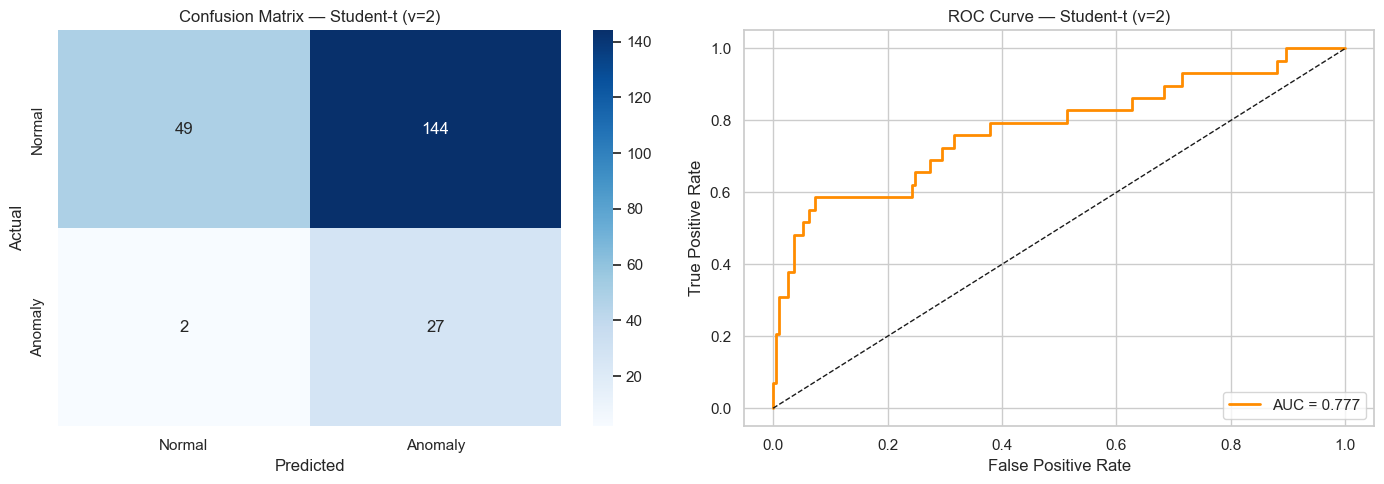

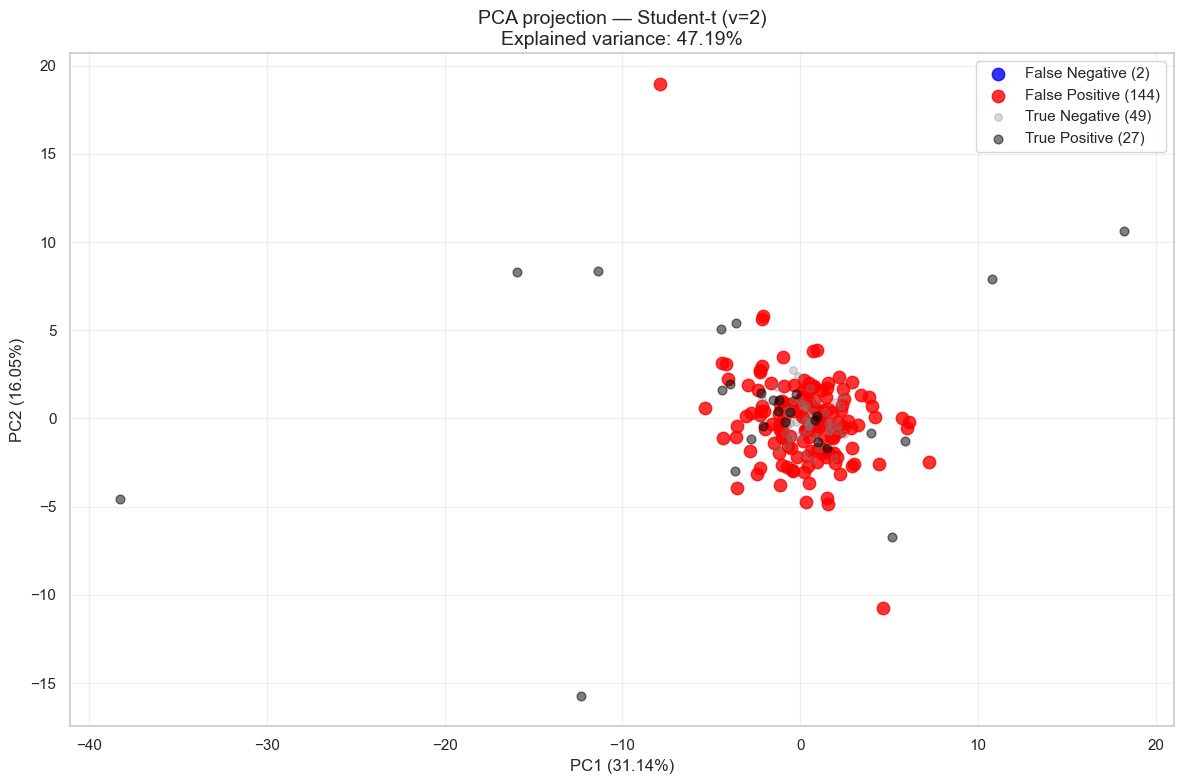

In [29]:
# Tune threshold on CV using best nu
scores_cv_t = -student_t_log_pdf(X_cross_val, mu_t, sigma_t, best_nu)
best_thr_t, _ = tune_threshold(scores_cv_t, y_cross_val, higher_is_anomalous=True)

# Evaluate on test set
scores_test_t = -student_t_log_pdf(X_test, mu_t, sigma_t, best_nu)
pred_t = (scores_test_t > best_thr_t).astype(int)

evaluate_model(y_test, pred_t, scores_test_t, f'Student-t (ν={best_nu})')
visualize_pca(X_test, y_test, pred_t, f'Student-t (ν={best_nu})')

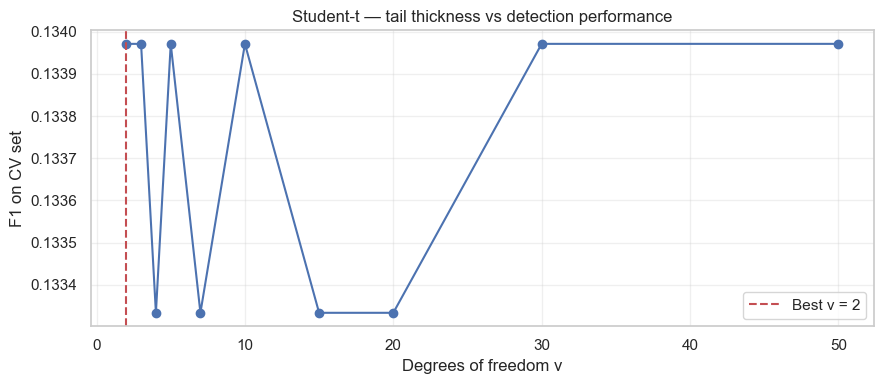

,nu,F1_cv
0,2,0.133971
1,3,0.133971
2,4,0.133333
3,5,0.133971
4,7,0.133333
5,10,0.133971
6,15,0.133333
7,20,0.133333
8,30,0.133971
9,50,0.133971


In [30]:
# Show how tail thickness (nu) affects F1 — diagnostic plot
nu_f1 = []
for nu in nu_candidates:
    scores_cv_ = -student_t_log_pdf(X_cross_val, mu_t, sigma_t, nu)
    _, f1_ = tune_threshold(scores_cv_, y_cross_val, higher_is_anomalous=True)
    nu_f1.append({'nu': nu, 'F1_cv': f1_})

nu_df = pd.DataFrame(nu_f1)
plt.figure(figsize=(9, 4))
plt.plot(nu_df['nu'], nu_df['F1_cv'], 'bo-')
plt.axvline(best_nu, color='r', linestyle='--', label=f'Best ν = {best_nu}')
plt.xlabel('Degrees of freedom ν')
plt.ylabel('F1 on CV set')
plt.title('Student-t — tail thickness vs detection performance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
display(nu_df)

---

# 📊 Model 7 — Factor Model Anomaly Detection (PCA Reconstruction Error)

This model is directly inspired by **quantitative risk management practice**.

Every major risk system (Barra, Axioma, Bloomberg PORT) decomposes asset returns into:
- **Systematic factors** — broad market drivers (equity beta, duration, credit spread, FX, ...)
- **Idiosyncratic risk** — asset-specific noise

We replicate this with PCA:
1. Fit PCA on **normal training data only** → the principal components are the *latent market factors*.
2. For any new observation, compute the **reconstruction error** — how much of the week's return is *not explained* by the learned factors.
3. A **high reconstruction error** means the week exhibits unusual patterns that don't align with any known factor regime → anomalous.

$$\text{score}(x) = \|x - \hat{x}\|^2 = \|x - W W^T x\|^2$$

where $W$ contains the top-$k$ eigenvectors fitted on normal data.

> 📎 This is the **linear autoencoder** equivalent — but fully interpretable through the lens of factor models.
> The number of factors $k$ is tuned on the CV set.

<br>

Selecting number of PCA factors k on CV set...
Best k (number of factors): 1
Variance explained by 1 factors: 24.08%


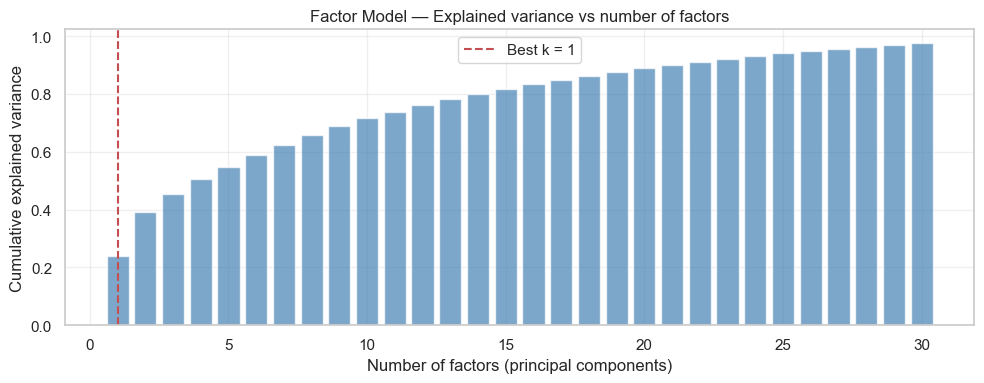

In [31]:
# ── Factor Model: PCA Reconstruction Error ────────────────────────────────

def pca_reconstruction_error(X, pca_model):
    """Compute reconstruction error ||x - PCA(x)||^2 for each sample."""
    X_reconstructed = pca_model.inverse_transform(pca_model.transform(X))
    return np.mean((X - X_reconstructed) ** 2, axis=1)


# Select number of factors k on CV set (maximise F1)
print("Selecting number of PCA factors k on CV set...")
k_candidates = list(range(1, min(20, X_train.shape[1])))
best_k, best_f1_k = 1, 0.0

for k in k_candidates:
    pca_k = PCA(n_components=k).fit(X_train)
    err_cv = pca_reconstruction_error(X_cross_val, pca_k)
    _, f1_k = tune_threshold(err_cv, y_cross_val, higher_is_anomalous=True)
    if f1_k > best_f1_k:
        best_f1_k, best_k = f1_k, k

print(f"Best k (number of factors): {best_k}")

# Fit final PCA with best k
pca_factor = PCA(n_components=best_k).fit(X_train)
explained = pca_factor.explained_variance_ratio_.sum()
print(f"Variance explained by {best_k} factors: {explained:.2%}")

# Plot explained variance vs k
evr = PCA(n_components=min(30, X_train.shape[1])).fit(X_train).explained_variance_ratio_
plt.figure(figsize=(10, 4))
plt.bar(range(1, len(evr)+1), np.cumsum(evr), color='steelblue', alpha=0.7)
plt.axvline(best_k, color='r', linestyle='--', label=f'Best k = {best_k}')
plt.xlabel('Number of factors (principal components)')
plt.ylabel('Cumulative explained variance')
plt.title('Factor Model — Explained variance vs number of factors')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


  Factor Model (k=1)
  Precision : 0.6429
  Recall    : 0.3103
  F1 Score  : 0.4186
  AUC       : 0.7836


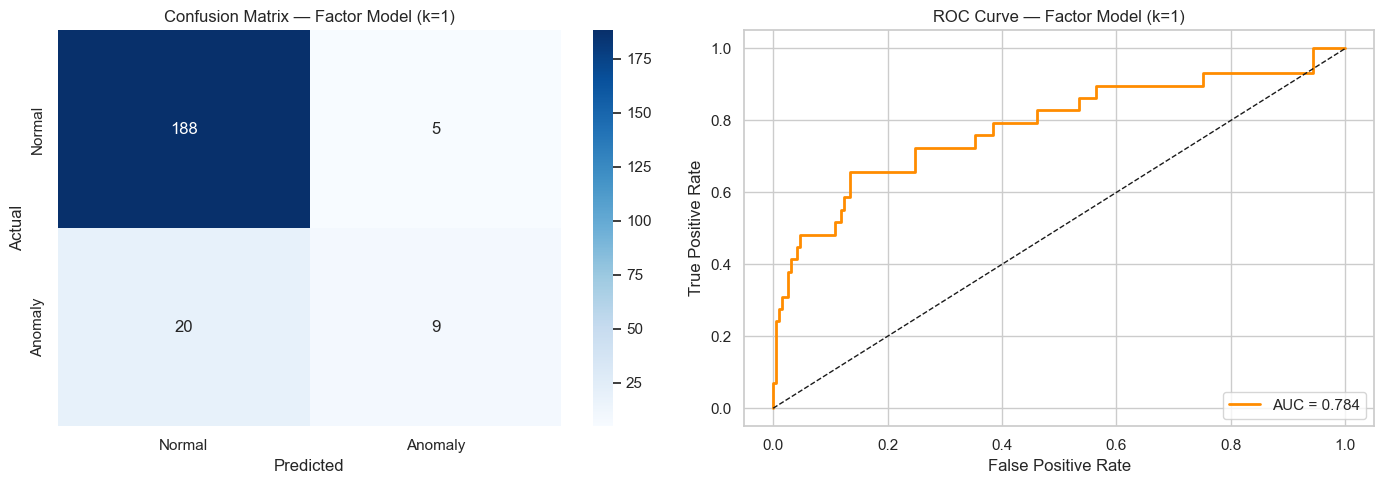

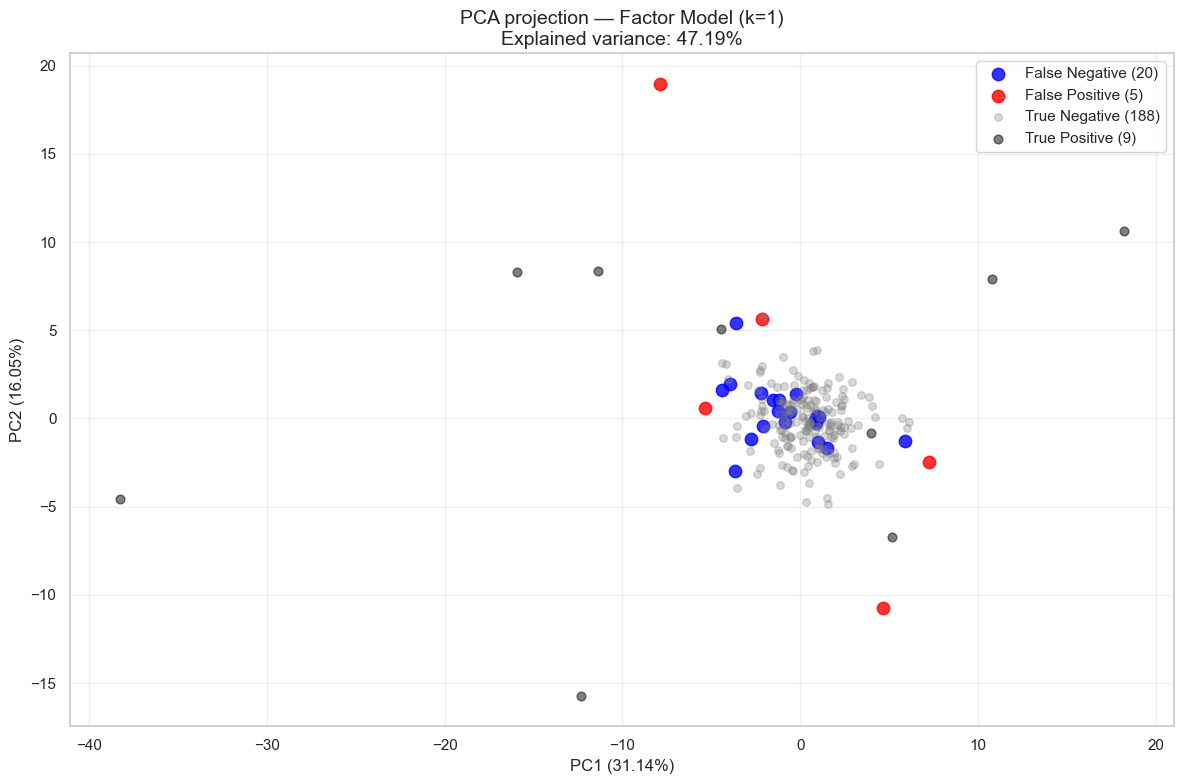

In [32]:
# Tune threshold on CV and evaluate on test
err_cv_factor = pca_reconstruction_error(X_cross_val, pca_factor)
best_thr_factor, _ = tune_threshold(err_cv_factor, y_cross_val, higher_is_anomalous=True)

err_test_factor = pca_reconstruction_error(X_test, pca_factor)
pred_factor = (err_test_factor > best_thr_factor).astype(int)

evaluate_model(y_test, pred_factor, err_test_factor, f'Factor Model (k={best_k})')
visualize_pca(X_test, y_test, pred_factor, f'Factor Model (k={best_k})')

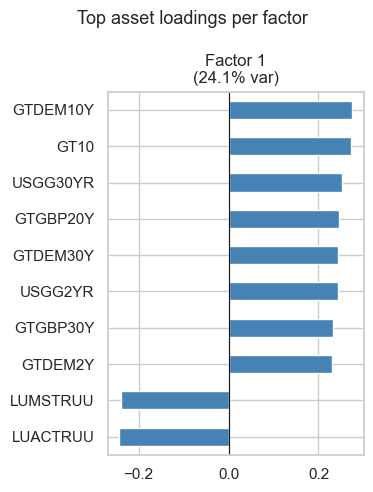

In [33]:
# Factor interpretation — which assets load most on each factor
feature_names = stationary_df.columns.tolist()
n_show = min(5, best_k)   # show top factors

fig, axes = plt.subplots(1, n_show, figsize=(4 * n_show, 5))
if n_show == 1:
    axes = [axes]

for fi in range(n_show):
    loadings = pd.Series(pca_factor.components_[fi], index=feature_names)
    top = loadings.abs().nlargest(10).index
    loadings[top].sort_values().plot(kind='barh', ax=axes[fi], color='steelblue')
    axes[fi].set_title(f'Factor {fi+1}\n({pca_factor.explained_variance_ratio_[fi]:.1%} var)')
    axes[fi].axvline(0, color='k', linewidth=0.8)

plt.suptitle('Top asset loadings per factor', fontsize=13)
plt.tight_layout()
plt.show()

---

# 📊 Model 8 — Graphical Lasso (Sparse Precision Matrix)

Both the MVG baseline and Ledoit-Wolf estimate a **dense** covariance matrix.
But in practice, most pairs of assets are only weakly related once you condition on the others.

**Graphical Lasso (GLASSO)** imposes **L1 sparsity on the precision matrix** $\Theta = \Sigma^{-1}$:

$$\hat{\Theta} = \arg\max_{\Theta \succ 0} \left[ \log\det\Theta - \text{tr}(S\Theta) - \alpha \|\Theta\|_1 \right]$$

- $S$ = sample covariance, $\alpha$ = sparsity penalty (larger $\alpha$ → fewer edges in the graph).
- A zero in $\Theta_{ij}$ means assets $i$ and $j$ are **conditionally independent** given all others.
- Anomaly score = **Mahalanobis distance** under the sparse precision matrix.

**Why it matters in finance:**
- Reveals the true conditional dependency graph between asset classes.
- Filters out spurious correlations — only real financial linkages survive.
- More robust than full covariance when features >> observations.
- Directly related to **graphical models** used in systemic risk research.

> 📎 `sklearn.covariance.GraphicalLassoCV` selects $\alpha$ automatically via cross-validation.

<br>

In [34]:
from sklearn.covariance import GraphicalLassoCV
import warnings

print("Fitting Graphical Lasso (this may take a minute — CV over alpha grid)...")

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    glasso = GraphicalLassoCV(
        alphas=10,          # number of alpha values to try in CV
        cv=5,
        max_iter=500,
        tol=1e-3,
        n_jobs=-1,
        assume_centered=False
    ).fit(X_train)

print(f"Best alpha (sparsity)    : {glasso.alpha_:.6f}")
sparsity = np.mean(glasso.precision_ == 0)
print(f"Precision matrix sparsity: {sparsity:.2%}  (fraction of zero entries)")
print(f"  → {int(sparsity * X_train.shape[1]**2)} zero entries out of {X_train.shape[1]**2} total")

Fitting Graphical Lasso (this may take a minute — CV over alpha grid)...
Best alpha (sparsity)    : 0.128945
Precision matrix sparsity: 79.02%  (fraction of zero entries)
  → 1394 zero entries out of 1764 total



  Graphical Lasso
  Precision : 0.1508
  Recall    : 0.9310
  F1 Score  : 0.2596
  AUC       : 0.7785


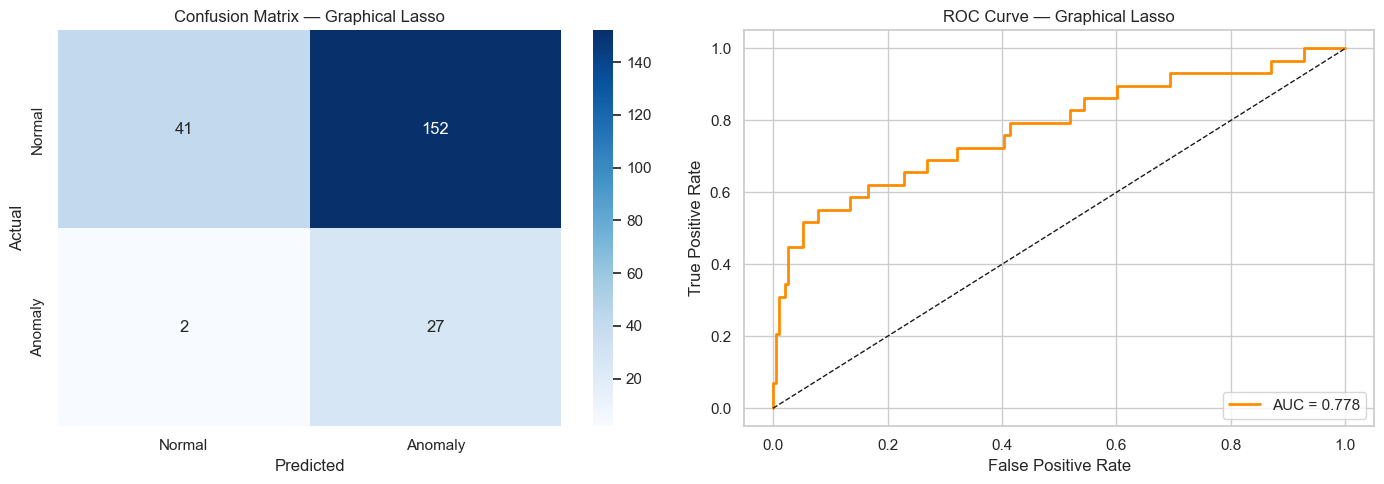

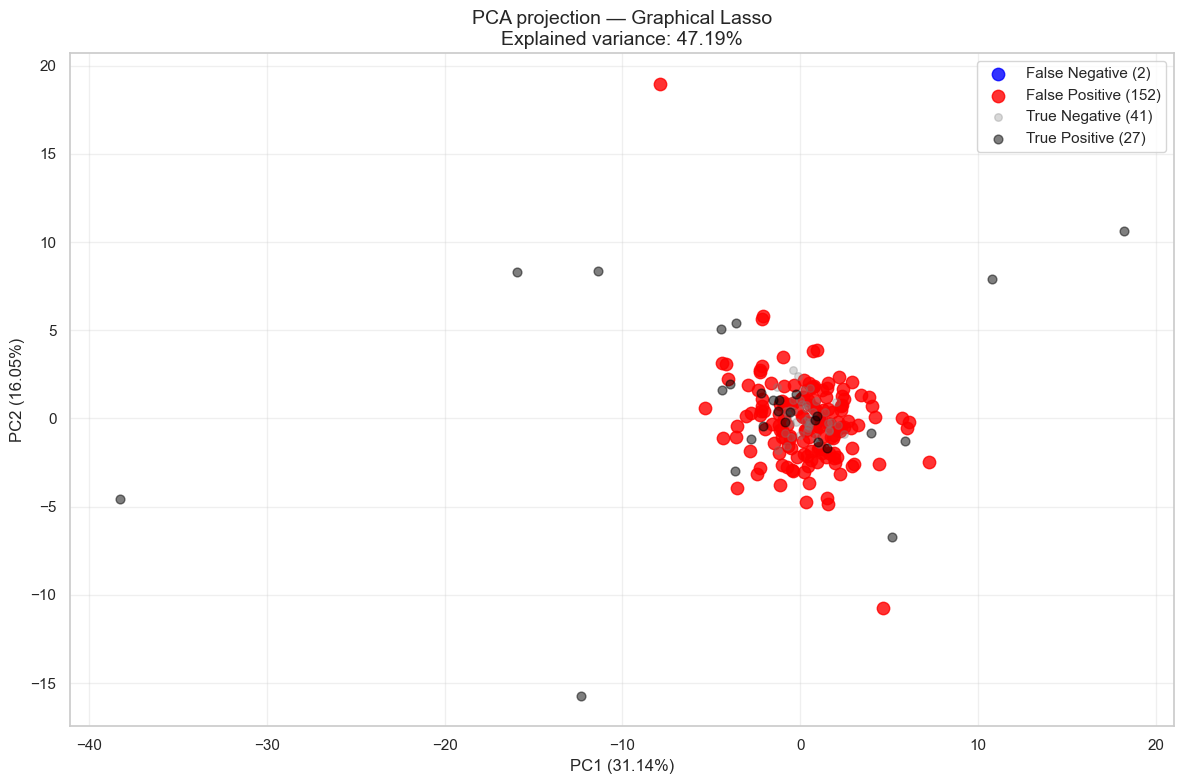

In [35]:
# Anomaly score = Mahalanobis distance under sparse precision matrix
def mahalanobis_glasso(X, mu, precision):
    """Mahalanobis distance using a precomputed precision matrix."""
    X_c = X - mu
    # (X-mu) @ Theta @ (X-mu)^T  — vectorised
    return np.einsum('ij,jk,ik->i', X_c, precision, X_c)


mu_gl    = glasso.location_
prec_gl  = glasso.precision_

# Score CV and tune threshold
score_cv_gl = mahalanobis_glasso(X_cross_val, mu_gl, prec_gl)
best_thr_gl, _ = tune_threshold(score_cv_gl, y_cross_val, higher_is_anomalous=True)

# Evaluate on test
score_test_gl = mahalanobis_glasso(X_test, mu_gl, prec_gl)
pred_gl = (score_test_gl > best_thr_gl).astype(int)

evaluate_model(y_test, pred_gl, score_test_gl, 'Graphical Lasso')
visualize_pca(X_test, y_test, pred_gl, 'Graphical Lasso')

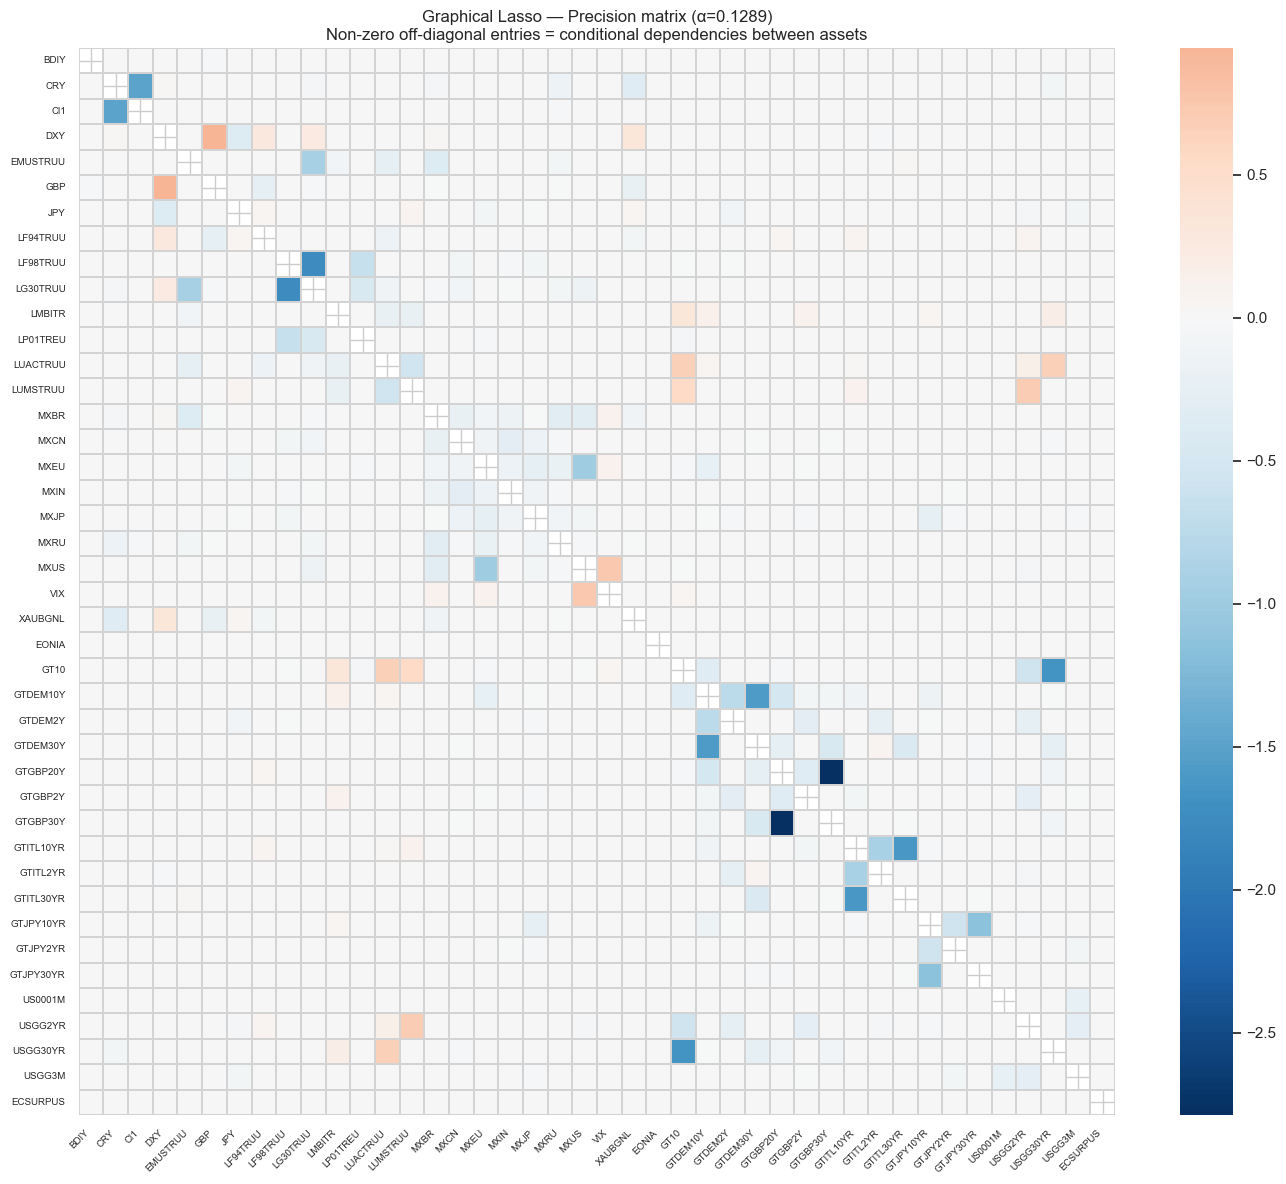


Top 15 strongest conditional dependencies:


,Asset A,Asset B,Precision,Strength
145,GTGBP20Y,GTGBP30Y,-2.788525,2.788525
45,LF98TRUU,LG30TRUU,-1.763007,1.763007
125,GT10,USGG30YR,-1.655590,1.655590
154,GTITL10YR,GTITL30YR,-1.636768,1.636768
127,GTDEM10Y,GTDEM30Y,-1.567088,1.567088
1,CRY,Cl1,-1.490742,1.490742
159,GTJPY10YR,GTJPY30YR,-1.137652,1.137652
99,MXEU,MXUS,-0.983856,0.983856
9,DXY,GBP,0.942875,0.942875
16,EMUSTRUU,LG30TRUU,-0.932423,0.932423


In [36]:
# Visualise the conditional dependency graph (precision matrix heatmap)
feature_names = stationary_df.columns.tolist()

prec_df = pd.DataFrame(glasso.precision_, index=feature_names, columns=feature_names)

# Mask the diagonal (it's always large — not informative for the graph)
mask = np.eye(len(feature_names), dtype=bool)

plt.figure(figsize=(14, 12))
sns.heatmap(prec_df, mask=mask, cmap='RdBu_r', center=0,
            xticklabels=True, yticklabels=True,
            linewidths=0.3, linecolor='lightgray')
plt.title(f'Graphical Lasso — Precision matrix (α={glasso.alpha_:.4f})\n'
          f'Non-zero off-diagonal entries = conditional dependencies between assets',
          fontsize=12)
plt.xticks(fontsize=7, rotation=45, ha='right')
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

# Top-20 strongest conditional dependencies
off_diag = []
n = len(feature_names)
for i in range(n):
    for j in range(i+1, n):
        if glasso.precision_[i, j] != 0:
            off_diag.append({
                'Asset A': feature_names[i],
                'Asset B': feature_names[j],
                'Precision': glasso.precision_[i, j],
                'Strength': abs(glasso.precision_[i, j])
            })
dep_df = pd.DataFrame(off_diag).sort_values('Strength', ascending=False)
print("\nTop 15 strongest conditional dependencies:")
display(dep_df.head(15))

---

# 📋 Final Results Summary — Simone

All models evaluated on the same held-out test set.

<br>


  SIMONE — RESULTS SUMMARY


,Model,Precision,Recall,F1,AUC
0,MVG Asymmetric,0.6087,0.4828,0.5385,0.2868
1,Elliptic Envelope,0.75,0.3103,0.439,0.7629
2,Factor Model (k=1),0.6429,0.3103,0.4186,0.7836
3,Student-t (ν=2),0.1579,0.931,0.27,0.7768
4,MVG Baseline,0.1552,0.931,0.266,0.7768
5,MVG Ledoit-Wolf,0.1552,0.931,0.266,0.7833
6,Graphical Lasso,0.1508,0.931,0.2596,0.7785
7,MVG CDF-based,0.1412,0.8621,0.2427,0.7659


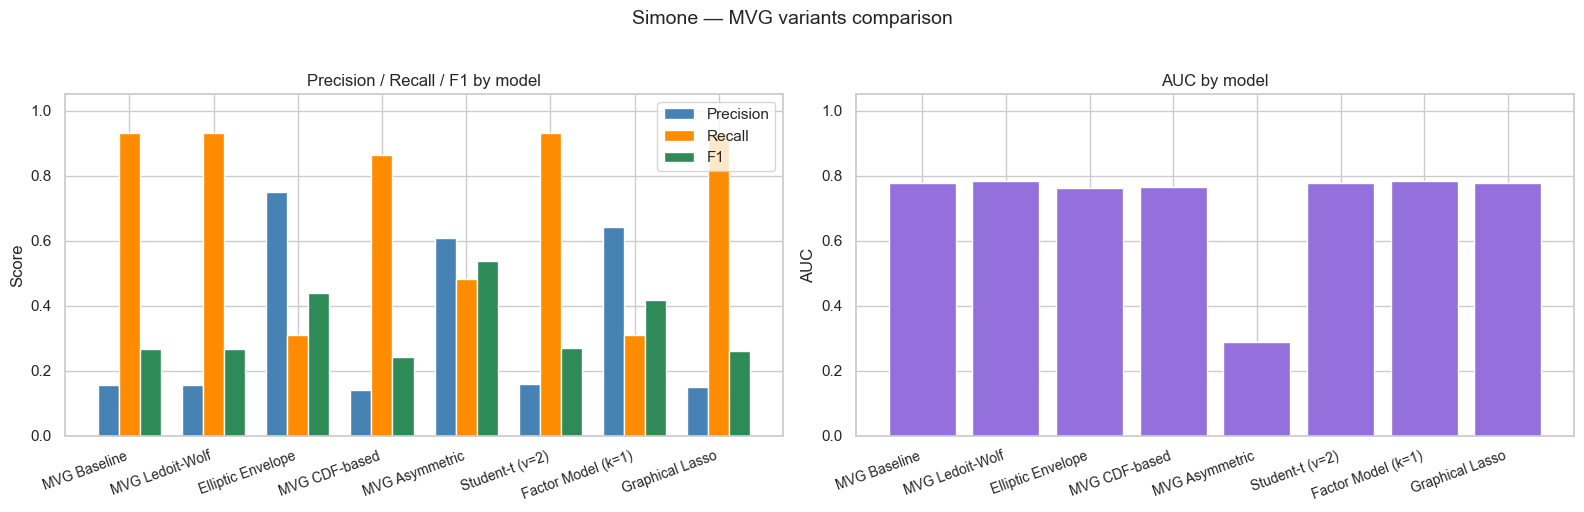

In [37]:
# Print and display the full results table
print("\n" + "="*60)
print("  SIMONE — RESULTS SUMMARY")
print("="*60)
display(results_df.sort_values('F1', ascending=False).reset_index(drop=True))

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

models = results_df['Model']
x = np.arange(len(models))
width = 0.25

axes[0].bar(x - width, results_df['Precision'], width, label='Precision', color='steelblue')
axes[0].bar(x,         results_df['Recall'],    width, label='Recall',    color='darkorange')
axes[0].bar(x + width, results_df['F1'],        width, label='F1',        color='seagreen')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=20, ha='right', fontsize=10)
axes[0].set_ylabel('Score')
axes[0].set_title('Precision / Recall / F1 by model')
axes[0].legend()
axes[0].set_ylim(0, 1.05)

axes[1].bar(x, results_df['AUC'], color='mediumpurple')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=20, ha='right', fontsize=10)
axes[1].set_ylabel('AUC')
axes[1].set_title('AUC by model')
axes[1].set_ylim(0, 1.05)

plt.suptitle('Simone — MVG variants comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [38]:
# Export results for merge with other persons
results_df.to_csv('results_simone_walkforward.csv', index=False)
print("Results saved to results_simone_walkforward.csv")
print("\nShare this file with the group for the final merge.")
display(results_df)

Results saved to results_simone_walkforward.csv

Share this file with the group for the final merge.


,Model,Precision,Recall,F1,AUC
0,MVG Baseline,0.1552,0.931,0.266,0.7768
1,MVG Ledoit-Wolf,0.1552,0.931,0.266,0.7833
2,Elliptic Envelope,0.75,0.3103,0.439,0.7629
3,MVG CDF-based,0.1412,0.8621,0.2427,0.7659
4,MVG Asymmetric,0.6087,0.4828,0.5385,0.2868
5,Student-t (ν=2),0.1579,0.931,0.27,0.7768
6,Factor Model (k=1),0.6429,0.3103,0.4186,0.7836
7,Graphical Lasso,0.1508,0.931,0.2596,0.7785
